In [1]:
# -- CELL 1: Imports & Constants --

import os, re, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import requests
from rasterio.features import rasterize
from rasterio.transform import from_bounds as make_transform
from rasterio.crs import CRS
from shapely.geometry import box
from scipy.optimize import curve_fit

warnings.filterwarnings('ignore')


# -- Paths --
data_dir = './data/'
os.makedirs(data_dir, exist_ok=True)
asc_data_dir = './data/asc/'
os.makedirs(asc_data_dir, exist_ok=True)

# -- AOI bounds (full Lake Erie) --
lon_min, lat_min, lon_max, lat_max = -83.5, 41.2, -78.8, 43.0
RES = 0.01  # ~1.1 km grid spacing in degrees

# -- Heat flux parameters (Guest & Davidson 1991) --
# CH/CE: adapted from Cdn ranges in Guest and Davidson (1991, Table 1)
# via the Reynolds analogy (CH ~ Cdn); CE reduced ~10-15% for ice
# surfaces to reflect Stanton/Dalton number asymmetry.
# Ts: climatological estimates for Lake Erie first-year ice,
# consistent with Maykut (1978) framework adapted for Great Lakes
# conditions (milder than central Arctic). Sensitivity to Ts ±2°C
# tested in Cell 14 - p05 >= 1.14 at all composite days except day 5
# (p05=0.99; reduced n due to deduplication artifact); N=500, seed=42.
# Open water and lead Ts ≈ 0.2°C (freshwater near-freezing surface)
# Rubble Ts ≈ -3.0°C (deformed ice, partial snow cover)
# Smooth Ts ≈ -7.0°C (consolidated fast ice, snow-covered surface)

# -- Air density and thermodynamic constants --
# rho_a = 1.29 kg/m³ (standard Arctic boundary layer value)
# Cp = 1005 J/kg/K (specific heat of dry air at constant pressure)
# Lv = 2.5e6 J/kg (latent heat of vaporization at 0°C)
rho_a = 1.29
Cp    = 1005.0
Lv    = 2.5e6

flux_params = {
    # CH/CE: adapted from Cdn in Guest and Davidson (1991, Table 1)
    # Ts: climatological estimates for Lake Erie first-year ice,
    # consistent with Maykut (1978) framework adapted for Great Lakes
    # conditions. Sensitivity to Ts ±2°C tested in Cell 14.
    'open':   {'Ts':  0.2, 'CH': 1.50e-3, 'CE': 1.50e-3},
    'lead':   {'Ts':  0.2, 'CH': 1.55e-3, 'CE': 1.55e-3},
    'rubble': {'Ts': -3.0, 'CH': 2.10e-3, 'CE': 1.80e-3},
    'smooth': {'Ts': -7.0, 'CH': 1.20e-3, 'CE': 1.10e-3},
}

# -- Manual forcing overrides --
# Optional: override ERA5 forcing for specific dates.
# Format: {'YYYYMMDD': {'Ta': float, 'RH': float, 'U': float}}
# Leave empty ({}) to use ERA5 for all dates.
# Useful for sensitivity testing individual events or correcting
# known ERA5 anomalies without modifying the main dataset.
FORCING_OVERRIDES = {}

print("Cell 1 complete.")

Cell 1 complete.


In [2]:
# -- CELL 2: Download USNIC Files --
import requests, os, time
from datetime import datetime, timedelta

def download_usnic_asc(date, asc_data_dir='./data/asc/'):
    """Download USNIC Great Lakes ASCII 1275m grid for a given date."""
    os.makedirs(asc_data_dir, exist_ok=True)
    usnic_date = date[2:]
    out_path   = os.path.join(asc_data_dir, f'GL{usnic_date}_1275.asc')

    if os.path.exists(out_path):
        print(f"  {date}: already exists — skipping")
        return 'exists'

    dd, mm, yyyy = date[6:8], date[4:6], date[0:4]
    url = f"https://usicecenter.gov/File/DownloadArchive?prd=37{mm}{dd}{yyyy}"

    for attempt in range(3):
        try:
            r = requests.get(url, timeout=60)
            if r.status_code == 200 and len(r.content) > 10000:
                with open(out_path, 'wb') as f:
                    f.write(r.content)
                print(f"  {date}: downloaded ({len(r.content)/1e6:.1f} MB)")
                return 'success'
            elif r.status_code == 404:
                print(f"  {date}: not available (404)")
                return 'not_available'
            else:
                print(f"  {date}: unexpected status {r.status_code}, attempt {attempt+1}/3")
                time.sleep(2)
        except requests.exceptions.RequestException as e:
            if attempt < 2:
                print(f"  {date}: connection error, retrying ({attempt+1}/3)...")
                time.sleep(2)
            else:
                print(f"  {date}: failed — {e}")
                return 'error'

    return 'error'


def download_usnic_range(start_date, end_date, asc_data_dir='./data/asc/'):
    """Download USNIC ASC files for winter months only (Dec–Mar)."""
    start = datetime.strptime(start_date, '%Y%m%d')
    end   = datetime.strptime(end_date,   '%Y%m%d')
    delta = (end - start).days + 1

    winter_months = [12, 1, 2, 3]

    winter_dates = [
        (start + timedelta(days=i)).strftime('%Y%m%d')
        for i in range(delta)
        if (start + timedelta(days=i)).month in winter_months
    ]
    print(f"Downloading {len(winter_dates)} winter dates: {start_date} → {end_date}")

    success      = []
    not_available = []
    error_dates  = []
    skipped      = []

    for i in range(delta):
        dt     = start + timedelta(days=i)
        date   = dt.strftime('%Y%m%d')

        if dt.month not in winter_months:
            skipped.append(date)
            continue

        result = download_usnic_asc(date, asc_data_dir)

        if result in ('success', 'exists'):
            success.append(date)
        elif result == 'not_available':
            not_available.append(date)
        elif result == 'error':
            error_dates.append(date)

        time.sleep(0.3)

    print(f"\nDownloaded:     {len(success)}")
    print(f"Not available:  {len(not_available)}")
    print(f"Errors:         {len(error_dates)}")
    print(f"Skipped:        {len(skipped)}")

    if not_available:
        print(f"\nNot available (404):")
        for d in not_available:
            print(f"  {d}")

    if error_dates:
        print(f"\nErrors (connection failures — worth retrying):")
        for d in error_dates:
            print(f"  {d}")

    return success, not_available, error_dates


# -- Download instructions --
# Data already downloaded: Dec–Mar winters 2010–2026 (2,063 files)
# Location: ./data/asc/GL{YYMMDD}_1275.asc
# Known gaps: January 2010 (no USNIC archive coverage for that period)
#
# To update or re-download, uncomment and run:
# available, not_available, error_dates = download_usnic_range('20101201', '20260410')
#
# Requires: internet access to usicecenter.gov
# Runtime: ~30–60 min for full date range (rate-limited by time.sleep(0.3))
print('Cell 2 complete.')

Cell 2 complete.


In [3]:
# -- CELL 3: Reusable Functions --
import requests, os, time
from datetime import datetime, timedelta
import rasterio
from rasterio.crs import CRS
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_origin
import geopandas as gpd
from rasterio.features import geometry_mask
from shapely.geometry import mapping

## -- Lake Erie polygon (cached) --
_erie_geom = None
_erie_geom_loaded = False

def _get_erie_geom():
    global _erie_geom, _erie_geom_loaded
    if _erie_geom_loaded:
        return _erie_geom  # returns None if failed, without retrying every date
    try:
        lakes = gpd.read_file('./data/ne_10m_lakes/ne_10m_lakes.shp')
        erie  = lakes[lakes['name'] == 'Lake Erie'].to_crs('EPSG:4326')
        _erie_geom = erie.geometry.iloc[0]
        print(f"Lake Erie polygon loaded: {_erie_geom.geom_type}")
    except Exception as e:
        print(f"WARNING: Could not load Lake Erie polygon ({e}). Falling back to bounding box.")
        _erie_geom = None
    _erie_geom_loaded = True
    return _erie_geom

def specific_humidity(T_c, RH_pct, P=101325.0):
    e = (RH_pct / 100.0) * 611.2 * np.exp(17.67 * T_c / (T_c + 243.5))
    return 0.622 * e / (P - 0.378 * e)


def stability_factor(Ta, Ts, U):
    # Louis (1979) bulk Richardson number stability correction.
    # Ri = (g/Tv) * (Ta - Ts) * z / U^2  (z=10m, Tv in K)
    # Unstable (Ri < 0): sf = (1 - 16*Ri)^0.5
    # Stable   (Ri >= 0): sf = max(1 - 5*Ri, 0.1)
    g    = 9.81
    z    = 10.0
    Tv   = Ta + 273.15
    U2   = max(float(U), 0.5) ** 2
    Ri   = (g / Tv) * (Ta - Ts) * z / U2
    if Ri < 0:
        return (1.0 - 16.0 * Ri) ** 0.5
    else:
        return max(1.0 - 5.0 * Ri, 0.1)

def get_forcing(date):
    """
    Returns (Ta, RH, U) for a given date from ERA5 reanalysis.
    
    All three forcing variables are derived from ERA5 to ensure
    spatial consistency over the lake domain and avoid the positive
    RH bias from nearshore CO-OPS stations, which measure
    lake-modified air rather than upstream CAO air mass properties.
    
    Ta: ERA5 lake-mean 2m temperature (°C)
    RH: derived from ERA5 2m dewpoint via Magnus formula (%)
    U:  ERA5 lake-mean 10m wind speed magnitude (m/s)
        10m is the reference height for Guest & Davidson (1991)
        transfer coefficients — no land-to-lake correction needed.
    """
    if date in FORCING_OVERRIDES:
        f = FORCING_OVERRIDES[date]
        return f['Ta'], f['RH'], f['U']

    date_ts = pd.Timestamp(f"{date[:4]}-{date[4:6]}-{date[6:]}")

    # Ta from ERA5
    era5_row = ta_df[ta_df['date'].dt.date == date_ts.date()]
    Ta = float(era5_row['Ta'].iloc[0]) if len(era5_row) > 0 else np.nan

    # RH from ERA5 dewpoint
    d2m_row = d2m_df[d2m_df['date'].dt.date == date_ts.date()]
    if len(d2m_row) > 0:
        Td = float(d2m_row['Td'].iloc[0])
        RH = 100.0 * np.exp(17.67 * Td / (Td + 243.5)) / \
                     np.exp(17.67 * Ta / (Ta + 243.5))
        RH = np.clip(RH, 1.0, 100.0)
    else:
        RH = 55.0

    # U from ERA5 10m wind — no land-to-lake correction needed
    wspd_row = wspd_df[wspd_df['date'].dt.date == date_ts.date()]
    U = float(wspd_row['U'].iloc[0]) if len(wspd_row) > 0 else np.nan

    return Ta, RH, U


def parse_usnic(date):
    """
    Parse USNIC Great Lakes ASCII 1275m grid for Lake Erie.

    USNIC encoding follows WMO SIGRID-3 concentration codes (WMO 2010):
      0           → open water
      10          → lead (1/10 concentration, lowest ice-covered class)
      30–70       → rubble (deformed medium-to-high concentration ice)
      80, 90      → smooth (8/10 and 9/10 concentration)
      91          → smooth (very close pack ice, 9+/10)
      92          → smooth (compact/consolidated ice, 10/10)

    Classification follows Section 3a of the paper. Values 91 and 92
    are assigned to the smooth class on the basis that at 9+/10 and
    10/10 concentration the ice surface is thermodynamically dominated
    by consolidated first-year ice, consistent with the smooth
    parameterization of Guest and Davidson (1991).

    Grid is reprojected from EPSG:3857 to EPSG:4326 using
    nearest-neighbour resampling and masked to the Lake Erie
    polygon from Natural Earth 10m lakes dataset.
    """  
    usnic_date = date[2:]
    asc_path   = os.path.join(asc_data_dir, f'GL{usnic_date}_1275.asc')

    if not os.path.exists(asc_path):
        print(f"  [{date}] File not found: {asc_path}")
        return None

    # -- Read header --
    header     = {}
    data_start = 0
    with open(asc_path, 'r') as f:
        for i, line in enumerate(f):
            parts = line.strip().split()
            if len(parts) == 2 and parts[0].lower() in [
                    'ncols','nrows','xllcorner','yllcorner',
                    'cellsize','nodata_value']:
                header[parts[0].lower()] = float(parts[1])
                data_start = i + 1
            elif i >= 6:
                break

    ncols    = int(header['ncols'])
    nrows    = int(header['nrows'])
    xll      = header['xllcorner']
    yll      = header['yllcorner']
    cellsize = header['cellsize']
    nodata   = header.get('nodata_value', -9999)

    # -- Read grid --
    grid = np.loadtxt(asc_path, skiprows=data_start,
                      dtype='float32', max_rows=nrows)
    grid[grid == nodata] = np.nan
    grid[grid == -1]     = np.nan

    print(f"  [{date}] Grid: {grid.shape}  "
          f"Valid: {np.isfinite(grid).sum():,}  "
          f"Values: {sorted(np.unique(grid[np.isfinite(grid)]).astype(int))}")

    # -- Reproject to Erie AOI --
    src_crs       = CRS.from_epsg(3857)
    src_transform = from_origin(xll, yll + nrows * cellsize,
                                cellsize, cellsize)

    aoi_h  = int((lat_max - lat_min) / RES)
    aoi_w  = int((lon_max - lon_min) / RES)
    aoi_tf = make_transform(lon_min, lat_min, lon_max, lat_max, aoi_w, aoi_h)

    ice_conc = np.full((aoi_h, aoi_w), np.nan, dtype='float32')

    reproject(
        source=grid,
        destination=ice_conc,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=aoi_tf,
        dst_crs=CRS.from_epsg(4326),
        resampling=Resampling.nearest,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )

    # -- Apply Lake Erie polygon mask --
    erie_geom = _get_erie_geom()
    if erie_geom is not None:
        erie_mask = geometry_mask(
            [mapping(erie_geom)],
            transform=aoi_tf,
            invert=True,
            out_shape=(aoi_h, aoi_w)
        )
        ice_conc[~erie_mask] = np.nan

    print(f"  [{date}] Erie: {aoi_h}×{aoi_w}  "
          f"Valid: {np.isfinite(ice_conc).sum():,}  "
          f"Max: {np.nanmax(ice_conc) if np.isfinite(ice_conc).any() else 0:.0f}%")

    # -- Classify pixels by USNIC encoding --
    open_water_mask = np.isfinite(ice_conc) & ((ice_conc == 0) | (ice_conc == 1))

    lead_mask = np.isfinite(ice_conc) & (
        ((ice_conc >= 10) & (ice_conc <= 20))
    )

    rubble_mask = np.isfinite(ice_conc) & (
        ((ice_conc >= 30) & (ice_conc <= 70)) |
        ((ice_conc >= 93) & (ice_conc <= 99))
    )

    smooth_mask = np.isfinite(ice_conc) & (
        (ice_conc == 80) | (ice_conc == 90) | (ice_conc == 91) | (ice_conc == 92)
    )

    lake_px = int(np.isfinite(ice_conc).sum())

    ice_pct = 100 * (lead_mask | rubble_mask | smooth_mask).sum() / lake_px \
              if lake_px > 0 else 0.0

    return {
        'ice_conc':        ice_conc,
        'open_water_mask': open_water_mask,
        'lead_mask':       lead_mask,
        'rubble_mask':     rubble_mask,
        'smooth_mask':     smooth_mask,
        'aoi_tf':          aoi_tf,
        'aoi_h':           aoi_h,
        'aoi_w':           aoi_w,
        'ice_pct':         ice_pct,
        'lake_px':         int(lake_px),
    }

print("Cell 3 complete.")

Cell 3 complete.


Already exists: ./data/era5_t2m_lake_erie_4x.nc
ERA5 loaded: 2010-01-01 → 2026-03-31
Ta range: -21.3°C to 18.1°C
Td range: -25.3°C to 14.0°C
U range:  1.3 to 12.5 m/s

Found 30 CAO events:
     onset        end  duration     min_Ta    mean_Ta
2010-01-29 2010-01-31         3 -12.091937 -11.354682
2011-01-22 2011-01-24         3 -14.228522 -13.179005
2011-02-09 2011-02-11         3 -12.766918 -11.951065
2013-01-22 2013-01-23         2 -12.595747 -12.505976
2014-01-07 2014-01-09         3 -21.273489 -15.496587
2014-01-21 2014-01-24         4 -15.774004 -13.483077
2014-01-28 2014-01-30         3 -17.535683 -14.847260
2014-02-06 2014-02-12         7 -14.502243 -12.086476
2014-02-26 2014-02-28         3 -15.911495 -12.419545
2014-03-03 2014-03-04         2 -14.604779 -14.545342
2015-01-06 2015-01-08         3 -14.202415 -11.777966
2015-01-13 2015-01-15         3 -13.154985 -11.207963
2015-02-15 2015-02-21         7 -20.220869 -15.810591
2015-02-23 2015-02-24         2 -16.284924 -15.130646
2

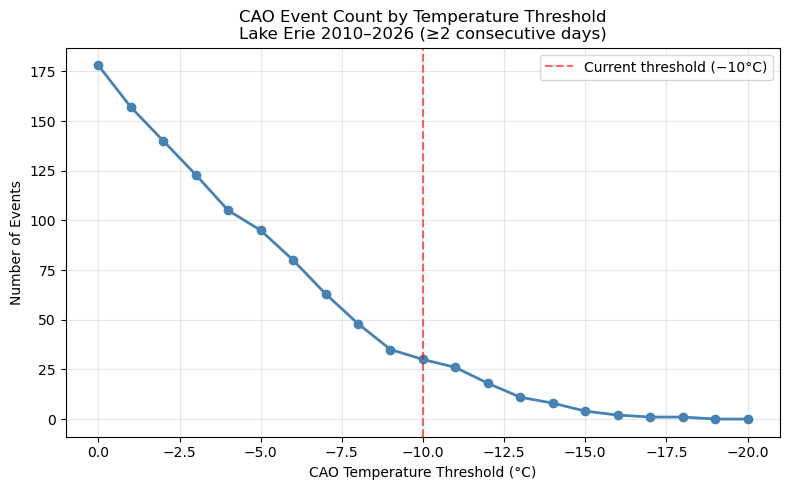

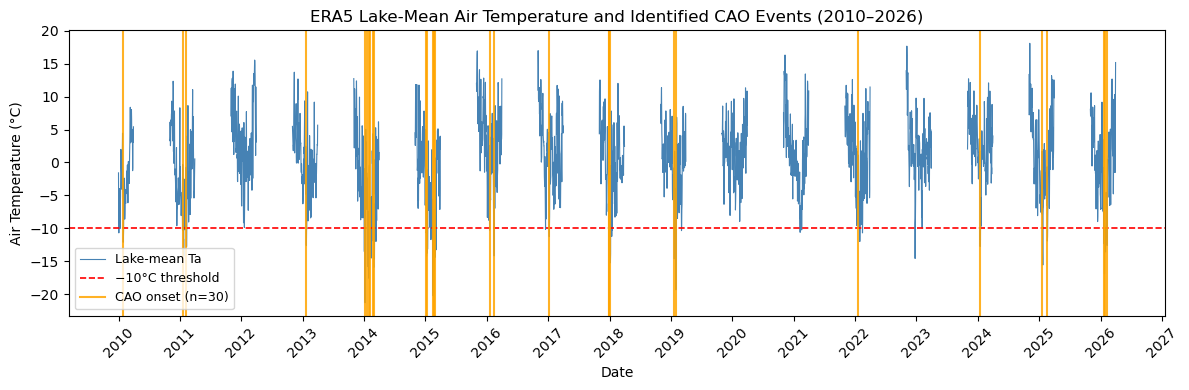

In [4]:
# -- CELL 4: Fetch ERA5 & Identify CAO Events --
# Criterion: ERA5 lake-mean Ta < -10°C for at least 2 consecutive days
# Threshold chosen to capture synoptic-scale polar air intrusions
# sufficient to drive significant turbulent heat flux over ice-covered Lake Erie.
# Duration criterion following Vavrus et al. (2006).
import cdsapi
import xarray as xr
import numpy as np
import pandas as pd
import os

# -- ERA5 fetch parameters --
ERA5_DIR  = './data/era5/'
ERA5_FILE = './data/era5_t2m_lake_erie_4x.nc'  # daily mean from 4 synoptic hours
os.makedirs(ERA5_DIR, exist_ok=True)

ERA5_NORTH, ERA5_SOUTH = 43.0, 41.2
ERA5_WEST,  ERA5_EAST  = 276.5, 281.2  # ERA5 uses 0-360 longitude

# Winter months only
WINTER_MONTHS = [11, 12, 1, 2, 3]
START_YEAR, END_YEAR = 2010, 2026

# -- Download year-by-year (single-year requests stay under CDS size limit) --
if not os.path.exists(ERA5_FILE):
    print("Downloading ERA5 year-by-year (4 synoptic hours per day)...")
    c = cdsapi.Client()
    yearly_files = []

    for year in range(START_YEAR, END_YEAR + 1):
        yr_file = os.path.join(ERA5_DIR, f'era5_erie_{year}.nc')
        yearly_files.append(yr_file)

        if os.path.exists(yr_file):
            print(f"  {year}: already exists — skipping")
            continue

        # Only include winter months that fall within this calendar year
        months = [m for m in WINTER_MONTHS
                  if not (m in [11, 12] and year == END_YEAR)]
        if not months:
            yearly_files.pop()
            continue

        print(f"  Downloading {year} (months {months})...")
        c.retrieve(
            'reanalysis-era5-single-levels',
            {
                'product_type': 'reanalysis',
                'variable':     ['2m_temperature', '2m_dewpoint_temperature',
                                 '10m_u_component_of_wind',
                                 '10m_v_component_of_wind'],
                'year':         str(year),
                'month':        [f'{m:02d}' for m in months],
                'day':          [f'{d:02d}' for d in range(1, 32)],
                'time':         ['00:00', '06:00', '12:00', '18:00'],
                'area':         [ERA5_NORTH, ERA5_WEST - 360,
                                 ERA5_SOUTH, ERA5_EAST - 360],
                'format':       'netcdf',
            },
            yr_file,
        )
        print(f"  {year}: saved ({os.path.getsize(yr_file)/1e6:.1f} MB)")

    # Concatenate all yearly files into one
    print("Concatenating yearly files...")
    ds = xr.open_mfdataset(yearly_files, combine='by_coords')
    ds.to_netcdf(ERA5_FILE)
    ds.close()
    print(f"Saved: {ERA5_FILE}")
else:
    print(f"Already exists: {ERA5_FILE}")

ds = xr.open_dataset(ERA5_FILE)
t2m = ds['t2m'] - 273.15  # K → °C
d2m = ds['d2m'] - 273.15  # K → °C

# -- Helper: spatial mean → daily mean across 4 synoptic hours --
def to_daily_df(da, varname):
    df = da.mean(dim=['latitude', 'longitude']).to_dataframe(name=varname).reset_index()
    time_col = 'valid_time' if 'valid_time' in df.columns else 'time'
    df = df.rename(columns={time_col: 'date'})
    df['date'] = pd.to_datetime(df['date'])
    df = df.groupby(df['date'].dt.date)[varname].mean().reset_index()
    df.columns = ['date', varname]
    df['date'] = pd.to_datetime(df['date'])
    return df.sort_values('date').reset_index(drop=True)

ta_df  = to_daily_df(t2m, 'Ta')
d2m_df = to_daily_df(d2m, 'Td')

wspd    = np.sqrt(ds['u10']**2 + ds['v10']**2)
wspd_df = to_daily_df(wspd, 'U')

print(f"ERA5 loaded: {ta_df['date'].min().date()} → {ta_df['date'].max().date()}")
print(f"Ta range: {ta_df['Ta'].min():.1f}°C to {ta_df['Ta'].max():.1f}°C")
print(f"Td range: {d2m_df['Td'].min():.1f}°C to {d2m_df['Td'].max():.1f}°C")
print(f"U range:  {wspd_df['U'].min():.1f} to {wspd_df['U'].max():.1f} m/s")

# -- Identify CAO events --
# Criterion: ERA5 lake-mean Ta < -10°C for ≥ 2 consecutive days
# following Vavrus et al. (2006) duration criterion.
# Absolute threshold chosen to capture polar air intrusions with
# meaningful air-surface temperature gradients over Lake Erie.
# Sensitivity: 48 events at -8°C, 30 at -10°C, 18 at -12°C.
# See Section 2 of paper for full justification.
CAO_THRESHOLD = -10.0  # °C
CAO_MIN_DAYS  = 2

ta_df['below_thresh'] = ta_df['Ta'] < CAO_THRESHOLD
ta_df['run_id'] = (ta_df['below_thresh'] != ta_df['below_thresh'].shift()).cumsum()

cao_events = []
for run_id, group in ta_df[ta_df['below_thresh']].groupby('run_id'):
    if len(group) >= CAO_MIN_DAYS:
        cao_events.append({
            'onset':    group['date'].iloc[0],
            'end':      group['date'].iloc[-1],
            'duration': len(group),
            'min_Ta':   group['Ta'].min(),
            'mean_Ta':  group['Ta'].mean(),
        })

cao_df = pd.DataFrame(cao_events)
print(f"\nFound {len(cao_df)} CAO events:")
print(cao_df.to_string(index=False))

# -- Cross-reference with available USNIC dates --
available_usnic = set()
for f in os.listdir('./data/asc/'):
    if f.startswith('GL') and f.endswith('_1275.asc'):
        yymmdd = f[2:8]
        yy = int(yymmdd[:2])
        yyyy = 2000 + yy if yy < 50 else 1900 + yy
        available_usnic.add(pd.Timestamp(f"{yyyy}{yymmdd[2:]}"))

print(f"\nUSNIC files available: {len(available_usnic)}")

# For each CAO, find USNIC dates within the event window + 7 days after
cao_usnic_dates = {}
for _, row in cao_df.iterrows():
    window_start = row['onset']
    window_end   = row['end'] + pd.Timedelta(days=7)
    matched = sorted([d for d in available_usnic
                      if window_start <= d <= window_end])
    if matched:
        cao_usnic_dates[row['onset'].strftime('%Y%m%d')] = [
            d.strftime('%Y%m%d') for d in matched
        ]

print(f"\nCAO events with USNIC coverage: {len(cao_usnic_dates)}")
for onset, dates in cao_usnic_dates.items():
    print(f"  CAO {onset}: {len(dates)} USNIC dates → {dates}")

# -- Build full date list --
all_usnic_dates = sorted([dt.strftime('%Y%m%d') for dt in available_usnic])

print(f"Total USNIC dates: {len(all_usnic_dates)}")

# -- CAO event count by temperature threshold --
# Shows sensitivity of event identification to threshold choice.
thresholds = list(range(0, -21, -1))
event_counts = []
for thresh in thresholds:
    ta_df['below_thresh'] = ta_df['Ta'] < thresh
    ta_df['run_id'] = (ta_df['below_thresh'] != ta_df['below_thresh'].shift()).cumsum()
    n = sum(1 for _, group in ta_df[ta_df['below_thresh']].groupby('run_id')
            if len(group) >= CAO_MIN_DAYS)
    event_counts.append(n)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, event_counts, 'o-', color='steelblue', lw=2, ms=6)
ax.set_xlabel('CAO Temperature Threshold (°C)')
ax.set_ylabel('Number of Events')
ax.set_title('CAO Event Count by Temperature Threshold\nLake Erie 2010–2026 (≥2 consecutive days)')
ax.axvline(-10, color='red', linestyle='--', alpha=0.6, label='Current threshold (−10°C)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()
plt.tight_layout()
plt.savefig('cao_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

# Restore original threshold after sensitivity plot
ta_df['below_thresh'] = ta_df['Ta'] < CAO_THRESHOLD
ta_df['run_id'] = (ta_df['below_thresh'] != ta_df['below_thresh'].shift()).cumsum()

import matplotlib.dates as mdates
from matplotlib.patches import Patch
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(12, 4))

# Fill date gaps with NaN to break the line across summer months
full_dates = pd.date_range(ta_df['date'].min(), ta_df['date'].max(), freq='D')
ta_plot = ta_df.set_index('date').reindex(full_dates).rename_axis('date').reset_index()

# Full Ta time series (gaps break the diagonal lines)
ax.plot(ta_plot['date'], ta_plot['Ta'], color='steelblue', lw=0.8)

# -10°C threshold
ax.axhline(-10, color='red', linestyle='--', lw=1.2)

# Vertical lines at each CAO onset
for _, row in cao_df.iterrows():
    ax.axvline(row['onset'], color='orange', lw=1.5, alpha=0.85)

# Legend
legend_handles = [
    mlines.Line2D([0], [0], color='steelblue', lw=0.8, label='Lake-mean Ta'),
    mlines.Line2D([0], [0], color='red', linestyle='--', lw=1.2, label='−10°C threshold'),
    mlines.Line2D([0], [0], color='orange', lw=1.5, alpha=0.85, label=f'CAO onset (n={len(cao_df)})')
]
ax.legend(handles=legend_handles, fontsize=9)

ax.set_xlabel('Date')
ax.set_ylabel('Air Temperature (°C)')
ax.set_title('ERA5 Lake-Mean Air Temperature and Identified CAO Events (2010–2026)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig_cao_events.png', dpi=150, bbox_inches='tight')
plt.show()

Lake Erie polygon loaded: Polygon


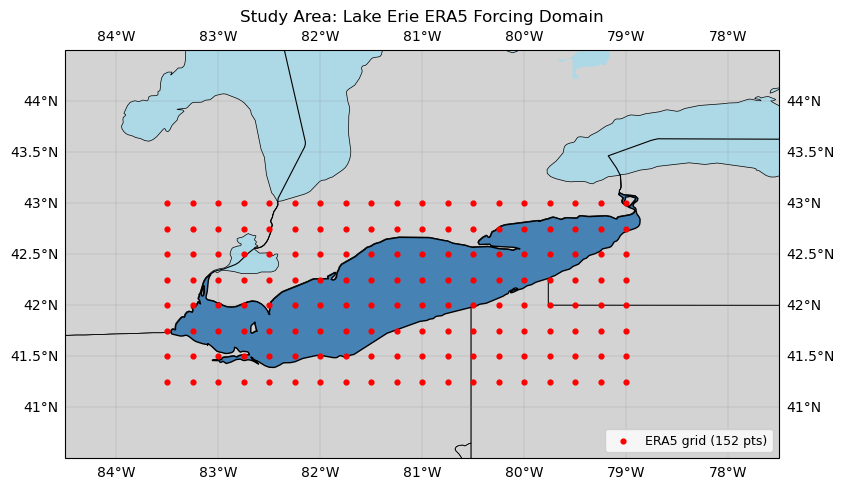

In [5]:
# -- CELL 5: Study Area Map --
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Extract ERA5 grid points from ds (already in memory from Cell 4)
# ERA5 stores longitude in 0–360; convert to -180–180 for plotting
era5_lats_1d = ds['latitude'].values
era5_lons_1d = ds['longitude'].values - 360.0  # 276–281 → -84 to -79

era5_lons_2d, era5_lats_2d = np.meshgrid(era5_lons_1d, era5_lats_1d)
era5_lons_flat = era5_lons_2d.flatten()
era5_lats_flat = era5_lats_2d.flatten()

# Lake Erie polygon from Cell 3
erie_geom = _get_erie_geom()  # returns a Shapely Polygon

fig, ax = plt.subplots(figsize=(9, 5),
                        subplot_kw={'projection': ccrs.PlateCarree()})

ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.LAKES, facecolor='lightblue', zorder=1)
ax.add_feature(cfeature.STATES, linewidth=0.5, zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, zorder=2)

# Lake Erie polygon
ax.add_geometries([erie_geom], crs=ccrs.PlateCarree(),
                  facecolor='steelblue', edgecolor='black',
                  linewidth=1.0, zorder=3, label='Lake Erie')

# ERA5 grid points
ax.scatter(era5_lons_flat, era5_lats_flat, s=12, c='red',
           transform=ccrs.PlateCarree(), zorder=4,
           label=f'ERA5 grid ({len(era5_lons_flat)} pts)')

ax.set_extent([-84.5, -77.5, 40.5, 44.5], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
ax.set_title('Study Area: Lake Erie ERA5 Forcing Domain', fontsize=12)
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('fig_study_area.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# -- CELL 6: Process All Dates --
# Parses USNIC charts, fetches met forcing, computes heat flux for every date
# Atmospheric stability correction (Louis 1979) applied inline.
DATES = all_usnic_dates
pixel_m2 = (RES * 111320.0) * (RES * 111320.0 * np.cos(np.deg2rad(42.0)))

usnic_results    = {}   # surface type masks keyed by date
flux_timeseries  = {}   # flux summary keyed by date

for date in DATES:
    print(f"\n{'='*50}")
    print(f"Processing {date}")
    print('='*50)

    # -- Parse USNIC --
    usnic = parse_usnic(date)
    if usnic is None:
        continue
    usnic_results[date] = usnic

    ice_pct = usnic['ice_pct']
    lake_px = usnic['lake_px']
    print(f"  Ice={ice_pct:.1f}%  "
      f"Lead={100*usnic['lead_mask'].sum()/lake_px:.1f}%  "
      f"Rubble={100*usnic['rubble_mask'].sum()/lake_px:.1f}%  "
      f"Smooth={100*usnic['smooth_mask'].sum()/lake_px:.1f}%")

    # -- Fetch atmospheric forcing --
    Ta_mean, RH_mean, U_mean = get_forcing(date)

    # -- Compute flux per surface type with stability correction --
    # QH = rho_a * Cp * CH * sf * U * (Ts - Ta)   [W/m²]
    # QE = rho_a * Lv * CE * sf * U * (qs - qa)   [W/m²]
    # Sign convention: positive = upward (away from surface)
    # QH > 0 when Ts > Ta (lake surface warmer than air) → CAO regime
    # QE > 0 when qs > qa (surface more moist than air) → evaporation
    # sf: Louis (1979) bulk Richardson number stability factor
    # sf > 1 in unstable conditions (CAO regime, Ts > Ta)
    qa        = specific_humidity(Ta_mean, RH_mean)
    flux_vals = {}
    for cat, p in flux_params.items():
        sf     = stability_factor(Ta_mean, p['Ts'], U_mean)
        qs_cat = specific_humidity(p['Ts'], 100.0)
        flux_vals[cat] = {
            'QH': rho_a * Cp * p['CH'] * sf * U_mean * (p['Ts'] - Ta_mean),
            'QE': rho_a * Lv * p['CE'] * sf * U_mean * (qs_cat - qa),
        }

    # -- Area-weighted totals --
    mask_lk = {
        'open':   usnic['open_water_mask'],
        'lead':   usnic['lead_mask'],
        'rubble': usnic['rubble_mask'],
        'smooth': usnic['smooth_mask'],
    }

    total_qh = sum(flux_vals[c]['QH'] * mask_lk[c].sum() * pixel_m2 / 1e9
                   for c in flux_params)
    total_qe = sum(flux_vals[c]['QE'] * mask_lk[c].sum() * pixel_m2 / 1e9
                   for c in flux_params)
    bowen    = total_qh / total_qe if abs(total_qe) > 10 else np.nan

    # -- Sub-grid enhancement -- 
    # Enhancement = hier_qh - base_qh [GW]
    # Measures additional QH from ice heterogeneity vs a hypothetical
    # lake where all ice pixels carry smooth ice parameters.
    # Positive values indicate leads/rubble contribute disproportionately
    # relative to their areal fraction (consistent with Gerbush 2008).
    # Threshold: ice_px > 500 and |base_qh| > 5 GW to prevent
    # spurious enhancement values when base_qh ≈ 0 (Ta ≈ Ts_smooth).
    ice_cats    = ['lead', 'rubble', 'smooth']
    ice_px      = sum(mask_lk[c].sum() for c in ice_cats)
    hier_qh     = sum(flux_vals[c]['QH'] * mask_lk[c].sum() * pixel_m2 / 1e9
                      for c in ice_cats)
    base_qh     = flux_vals['smooth']['QH'] * ice_px * pixel_m2 / 1e9
    enhancement = (hier_qh - base_qh
                   if ice_px > 500 and abs(base_qh) > 5 else np.nan)

    flux_timeseries[date] = {
        'Ta':          Ta_mean,
        'RH':          RH_mean,
        'U':           U_mean,
        'ice_pct':     ice_pct,
        'total_QH':    total_qh,
        'total_QE':    total_qe,
        'bowen':       bowen,
        'enhancement': enhancement,
        'flux_vals':   flux_vals,
        'mask_lk':     mask_lk,
    }

    print(f"  QH={total_qh:.1f} GW  QE={total_qe:.1f} GW  "
          f"Bowen={bowen:.2f}  Enhancement={enhancement:.1f} GW")
    gc.collect()

print(f"\nProcessed {len(flux_timeseries)} dates successfully.")


Processing 20101202
  [20101202] Grid: (1446, 1446)  Valid: 304,380  Values: [np.int64(0), np.int64(1), np.int64(60)]
  [20101202] Erie: 179×470  Valid: 18,707  Max: 0%
  Ice=0.0%  Lead=0.0%  Rubble=0.0%  Smooth=0.0%
  QH=545.9 GW  QE=887.2 GW  Bowen=0.62  Enhancement=nan GW

Processing 20101207
  [20101207] Grid: (1446, 1446)  Valid: 304,380  Values: [np.int64(0), np.int64(1), np.int64(57), np.int64(79), np.int64(91), np.int64(92)]
  [20101207] Erie: 179×470  Valid: 18,707  Max: 0%
  Ice=0.0%  Lead=0.0%  Rubble=0.0%  Smooth=0.0%
  QH=1229.6 GW  QE=1368.1 GW  Bowen=0.90  Enhancement=nan GW

Processing 20101209
  [20101209] Grid: (1446, 1446)  Valid: 304,380  Values: [np.int64(0), np.int64(1), np.int64(30), np.int64(50), np.int64(70), np.int64(90), np.int64(91)]
  [20101209] Erie: 179×470  Valid: 18,707  Max: 90%
  Ice=0.8%  Lead=0.0%  Rubble=0.0%  Smooth=0.8%
  QH=1461.8 GW  QE=1265.9 GW  Bowen=1.15  Enhancement=nan GW

Processing 20101214
  [20101214] Grid: (1446, 1446)  Valid: 304,3

In [7]:
# -- CELL 7: Build Deduplicated CAO Date List --
# Single source of truth for CAO composite date assignment.
# Each USNIC date is assigned to the earliest matching CAO onset window only.
# Used by both the composite analysis (Cell 10) and Monte Carlo (Cell 14)
# to guarantee they operate on identical date populations.

seen_dates_global = set()
cao_date_records = []  # flat list of {date, onset, day_offset, Ta, RH, U, pixel counts}

for onset_str, usnic_dates in sorted(cao_usnic_dates.items()):
    onset_dt = pd.to_datetime(onset_str)
    for date_str in sorted(usnic_dates):
        if date_str in seen_dates_global:
            continue
        if date_str not in flux_timeseries:
            continue
        r          = flux_timeseries[date_str]
        dt         = pd.to_datetime(date_str)
        day_offset = (dt - onset_dt).days
        seen_dates_global.add(date_str)

        cao_date_records.append({
            'onset':      onset_str,
            'date':       date_str,
            'day_offset': day_offset,
            'Ta':         r['Ta'],
            'RH':         r['RH'],
            'U':          r['U'],
            'ice_pct':    r['ice_pct'],
            'total_QH':   r['total_QH'],
            'total_QE':   r['total_QE'],
            'bowen':      r['bowen'],
            'n_open':     int(r['mask_lk']['open'].sum()),
            'n_lead':     int(r['mask_lk']['lead'].sum()),
            'n_rubble':   int(r['mask_lk']['rubble'].sum()),
            'n_smooth':   int(r['mask_lk']['smooth'].sum()),
        })

cao_records_df = pd.DataFrame(cao_date_records)
print(f"Total deduplicated CAO dates: {len(cao_records_df)}")
print(f"Day offset range: {cao_records_df['day_offset'].min()} to {cao_records_df['day_offset'].max()}")

Total deduplicated CAO dates: 249
Day offset range: 0 to 13


In [8]:
# -- CELL 8: Summary Table --
# -- Filter to cold dates only (Ta < 0°C) --
cold_dates = {d: v for d, v in flux_timeseries.items() if v['Ta'] < 0}
print(f"Cold dates: {len(cold_dates)} of {len(flux_timeseries)} total")

print(f"\n{'Date':<12} {'Ice%':>6} {'Ta(°C)':>8} {'U(m/s)':>8} "
      f"{'QH(GW)':>9} {'QE(GW)':>9} {'Bowen':>7} {'Enhance%':>10}")
print("-" * 75)

for date in sorted(cold_dates.keys()):
    r = cold_dates[date]
    print(f"{date:<12} {r['ice_pct']:>6.1f} {r['Ta']:>8.1f} "
          f"{r['U']:>8.1f} {r['total_QH']:>9.1f} "
          f"{r['total_QE']:>9.1f} {r['bowen']:>7.2f} "
          f"{r['enhancement']:>10.0f}")

print("-" * 75)

# Per-surface-type breakdown for each date
for date in sorted(cold_dates.keys()):
    r = cold_dates[date]
    print(f"\n{date} — per surface type:")
    print(f"  {'Type':<10} {'QH(W/m²)':>10} {'QE(W/m²)':>10} "
          f"{'Area(km²)':>12} {'TotalQH(GW)':>13}")
    for cat in ['open', 'lead', 'rubble', 'smooth']:
        area_km2 = r['mask_lk'][cat].sum() * pixel_m2 / 1e6
        qh_gw    = r['flux_vals'][cat]['QH'] * r['mask_lk'][cat].sum() * pixel_m2 / 1e9
        print(f"  {cat:<10} {r['flux_vals'][cat]['QH']:>10.1f} "
              f"{r['flux_vals'][cat]['QE']:>10.1f} "
              f"{area_km2:>12,.1f} {qh_gw:>13,.2f}")

# Enhancement on active-ice dates only (ice_pct >= 5%)
enh_vals = [v['enhancement'] for v in cold_dates.values() 
            if np.isfinite(v.get('enhancement', np.nan))]

print(f"\nSub-grid QH enhancement:")
print(f"  Median: {np.median(enh_vals):.0f} GW")
print(f"  Mean:   {np.mean(enh_vals):.0f} GW")
print(f"  Pct positive: {100*sum(e>0 for e in enh_vals)/len(enh_vals):.0f}%")
print(f"  N dates: {len(enh_vals)}")

Cold dates: 1017 of 2063 total

Date           Ice%   Ta(°C)   U(m/s)    QH(GW)    QE(GW)   Bowen   Enhance%
---------------------------------------------------------------------------
20101202        0.0     -1.9      7.0     545.9     887.2    0.62        nan
20101207        0.0     -3.8      7.9    1229.6    1368.1    0.90        nan
20101209        0.8     -6.0      3.8    1461.8    1265.9    1.15        nan
20101214        1.1     -9.6      8.9    3810.7    2367.2    1.61        nan
20101216       17.9     -6.9      4.5    1641.8    1229.7    1.34        nan
20101217       22.2     -4.7      4.4     930.7     854.0    1.09         88
20101218       19.5     -6.0      6.1    1524.2    1229.5    1.24        125
20101219       22.0     -6.5      4.1    1407.8    1058.9    1.33        114
20101220       22.7     -4.4      3.4     763.1     681.5    1.12         50
20101221       18.8     -4.1      2.6     655.1     604.8    1.08          3
20101222       19.0     -3.8      2.7     587

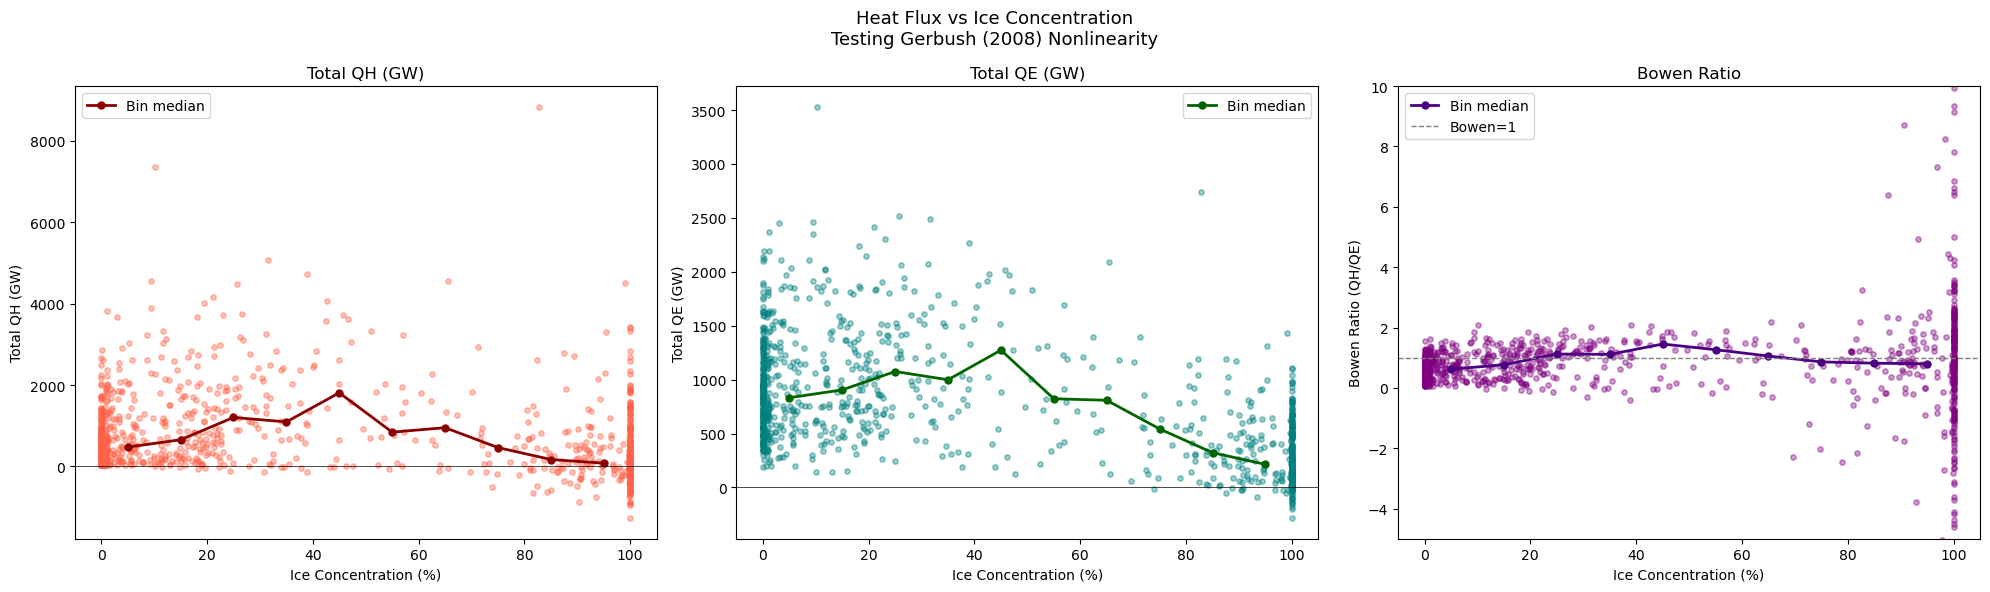

N cold dates plotted: 1017

Binned medians (10% bins):
  5%: QH=474 GW  QE=832 GW  Bowen=0.62
  15%: QH=655 GW  QE=905 GW  Bowen=0.77
  25%: QH=1203 GW  QE=1075 GW  Bowen=1.12
  35%: QH=1094 GW  QE=999 GW  Bowen=1.11
  45%: QH=1810 GW  QE=1273 GW  Bowen=1.45
  55%: QH=842 GW  QE=823 GW  Bowen=1.26
  65%: QH=952 GW  QE=808 GW  Bowen=1.06
  75%: QH=463 GW  QE=543 GW  Bowen=0.86
  85%: QH=170 GW  QE=323 GW  Bowen=0.82
  95%: QH=80 GW  QE=214 GW  Bowen=0.80


In [9]:
# -- CELL 9: Heat Flux vs Ice Concentration Scatter --
# Tests Gerbush (2008) nonlinearity: QH/QE vs ice concentration across all cold dates

import numpy as np

ice_vals   = np.array([v['ice_pct']   for v in cold_dates.values()])
qh_vals    = np.array([v['total_QH']  for v in cold_dates.values()])
qe_vals    = np.array([v['total_QE']  for v in cold_dates.values()])
bowen_vals = np.array([v['bowen']     for v in cold_dates.values()])

bin_edges   = np.arange(0, 110, 10)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

def bin_medians(x, y, edges, min_n=5):
    meds = []
    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        mask = (x >= lo) & (x <= hi) if i == len(edges)-2 else (x >= lo) & (x < hi)
        vals = y[mask]
        finite_vals = vals[np.isfinite(vals)]
        meds.append(np.nanmedian(finite_vals) if len(finite_vals) >= min_n else np.nan)
    return np.array(meds)

qh_meds    = bin_medians(ice_vals, qh_vals,    bin_edges)
qe_meds    = bin_medians(ice_vals, qe_vals,    bin_edges)
bowen_meds = bin_medians(ice_vals, bowen_vals, bin_edges)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Heat Flux vs Ice Concentration\nTesting Gerbush (2008) Nonlinearity', fontsize=13)

axes[0].scatter(ice_vals, qh_vals, color='tomato', alpha=0.4, s=15, zorder=1)
axes[0].plot(bin_centers, qh_meds, color='darkred', linewidth=2, marker='o', markersize=5, zorder=2, label='Bin median')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].set_xlabel('Ice Concentration (%)')
axes[0].set_ylabel('Total QH (GW)')
axes[0].set_title('Total QH (GW)')
axes[0].legend()

axes[1].scatter(ice_vals, qe_vals, color='teal', alpha=0.4, s=15, zorder=1)
axes[1].plot(bin_centers, qe_meds, color='darkgreen', linewidth=2, marker='o', markersize=5, zorder=2, label='Bin median')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xlabel('Ice Concentration (%)')
axes[1].set_ylabel('Total QE (GW)')
axes[1].set_title('Total QE (GW)')
axes[1].legend()

axes[2].scatter(ice_vals, bowen_vals, color='purple', alpha=0.4, s=15, zorder=1)
axes[2].plot(bin_centers, bowen_meds, color='indigo', linewidth=2, marker='o', markersize=5, zorder=2, label='Bin median')
axes[2].axhline(1, color='gray', linewidth=1, linestyle='--', label='Bowen=1')
axes[2].set_xlabel('Ice Concentration (%)')
axes[2].set_ylabel('Bowen Ratio (QH/QE)')
axes[2].set_title('Bowen Ratio')
axes[2].set_ylim(-5, 10)
axes[2].legend()

plt.tight_layout()
plt.savefig('flux_vs_ice.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"N cold dates plotted: {len(ice_vals)}")
print("\nBinned medians (10% bins):")
for i, c in enumerate(bin_centers):
    print(f"  {c:.0f}%: QH={qh_meds[i]:.0f} GW  QE={qe_meds[i]:.0f} GW  Bowen={bowen_meds[i]:.2f}")


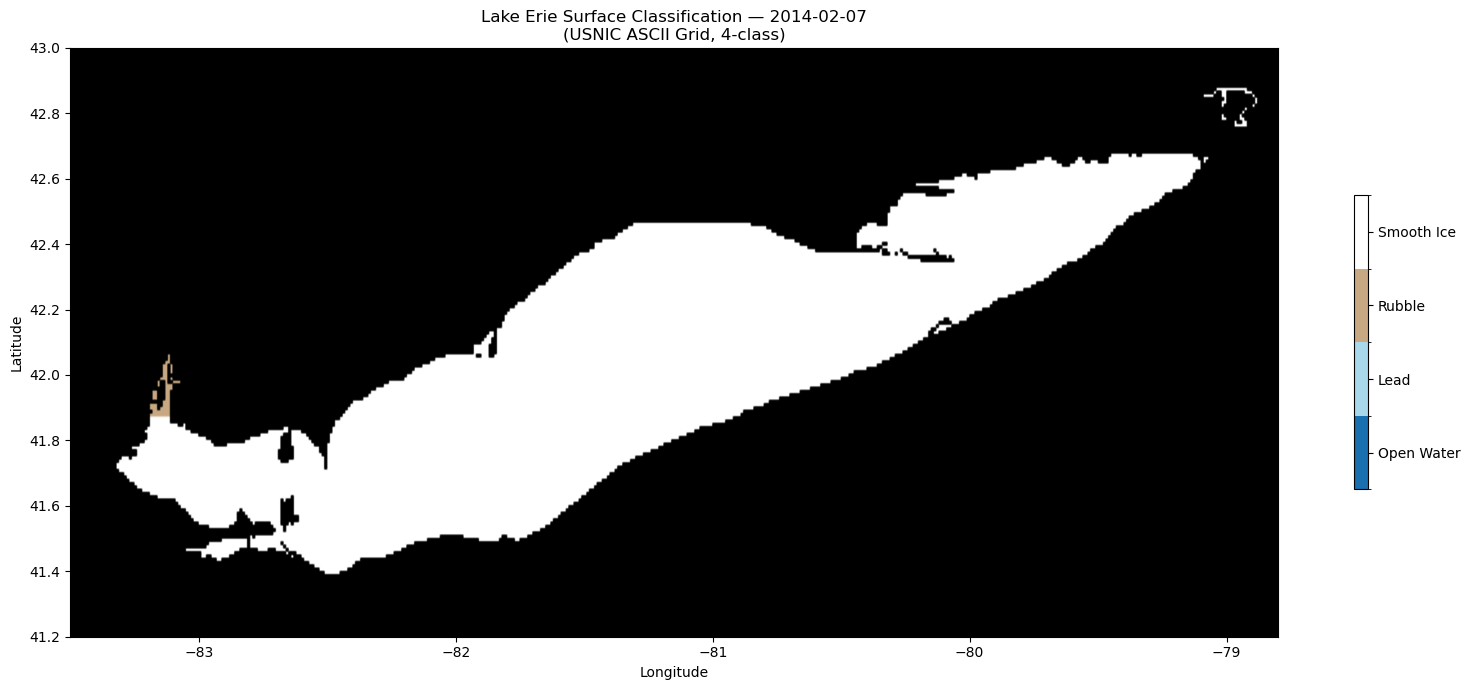

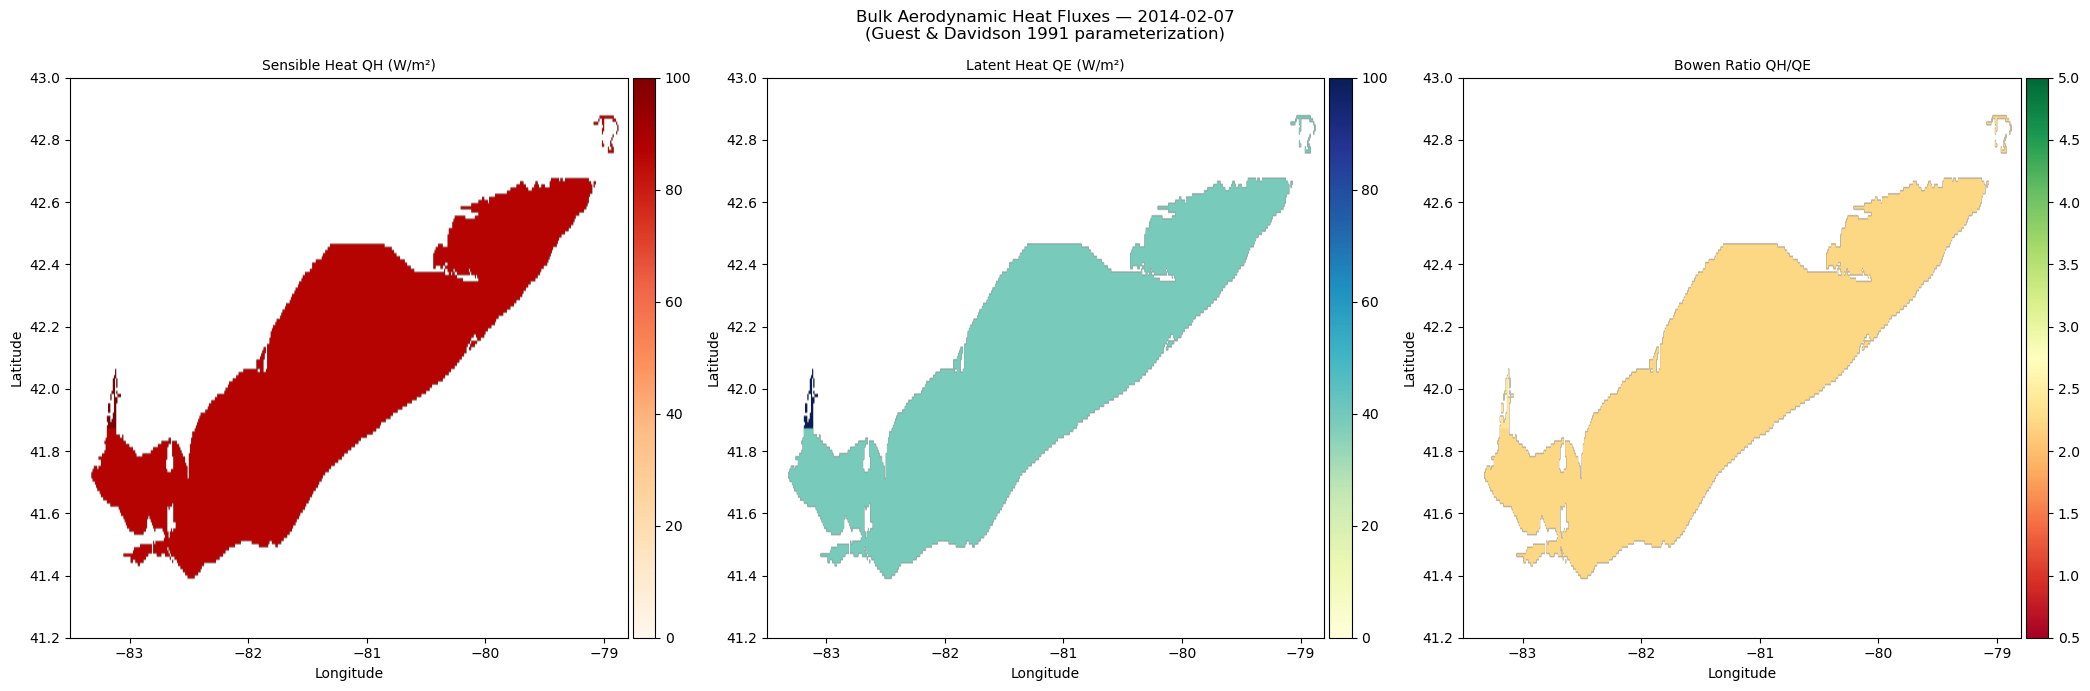

In [10]:
# -- CELL 10: Single Date Map --
from mpl_toolkits.axes_grid1 import make_axes_locatable
# Visualization date: 7 Feb 2014 — a representative mid-CAO date
# from the record-setting 2013-2014 polar vortex winter.
# Lake Erie was ~100% ice-covered with significant lead fraction.
# Produces Figure 1 (surface classification) and Figure 2 (heat flux maps)
# in the paper (Section 4.1).
viz_date = '20140207'
asf_date = f"{viz_date[:4]}-{viz_date[4:6]}-{viz_date[6:]}"

if viz_date not in usnic_results:
    print(f"No USNIC data for {viz_date}")
else:
    r  = usnic_results[viz_date]
    ft = flux_timeseries[viz_date]

    extent = [lon_min, lon_max, lat_min, lat_max]

    # -- 4-class USNIC map --
    cmap4 = mcolors.ListedColormap(['#1a6faf', '#a8d8ea', '#c8a882', '#ffffff'])
    norm4 = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap4.N)

    class_map = np.full((r['aoi_h'], r['aoi_w']), 255, dtype='uint8')
    class_map[r['open_water_mask']] = 0
    class_map[r['lead_mask']]       = 1
    class_map[r['rubble_mask']]     = 2
    class_map[r['smooth_mask']]     = 3

    fig, ax = plt.subplots(figsize=(16, 7))
    ax.set_facecolor("#000000")
    im = ax.imshow(np.ma.masked_where(class_map == 255, class_map),
                   cmap=cmap4, norm=norm4,
                   extent=extent, origin='upper', aspect='auto')
    cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], shrink=0.5)
    cbar.ax.set_yticklabels(['Open Water', 'Lead', 'Rubble', 'Smooth Ice'])
    ax.set_title(f"Lake Erie Surface Classification — {asf_date}\n"
                 f"(USNIC ASCII Grid, 4-class)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.savefig(f'classification_4class_{viz_date}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close('all')
    del class_map
    gc.collect()

    # -- Heat flux spatial maps --
    QH_arr = np.full((r['aoi_h'], r['aoi_w']), np.nan, dtype='float32')
    QE_arr = np.full((r['aoi_h'], r['aoi_w']), np.nan, dtype='float32')
    for cat in ['open', 'lead', 'rubble', 'smooth']:
        QH_arr[ft['mask_lk'][cat]] = ft['flux_vals'][cat]['QH']
        QE_arr[ft['mask_lk'][cat]] = ft['flux_vals'][cat]['QE']

    bowen_arr = np.where(
        np.isfinite(QE_arr) & (np.abs(QE_arr) > 1),
        QH_arr / QE_arr, np.nan).astype('float32')
    bowen_arr = np.clip(bowen_arr, 0.5, 5.0)

    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    fig.suptitle(f"Bulk Aerodynamic Heat Fluxes — {asf_date}\n"
                 f"(Guest & Davidson 1991 parameterization)", fontsize=12)

    panels = [
        (QH_arr,    'Sensible Heat QH (W/m²)', 'OrRd',   0,   100),
        (QE_arr,    'Latent Heat QE (W/m²)',   'YlGnBu', 0,   100),
        (bowen_arr, 'Bowen Ratio QH/QE',       'RdYlGn', 0.5, 5.0),
    ]
    for ax, (data_p, title, cmap, vmin, vmax) in zip(axes, panels):
        im_p = ax.imshow(np.ma.masked_invalid(data_p),
                         cmap=cmap, vmin=vmin, vmax=vmax,
                         extent=extent, origin='upper', aspect='auto')
        div = make_axes_locatable(ax)
        cax = div.append_axes('right', size='4%', pad=0.05)
        plt.colorbar(im_p, cax=cax)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    plt.tight_layout()
    plt.savefig(f'heat_flux_{viz_date}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close('all')
    del QH_arr, QE_arr, bowen_arr
    gc.collect()

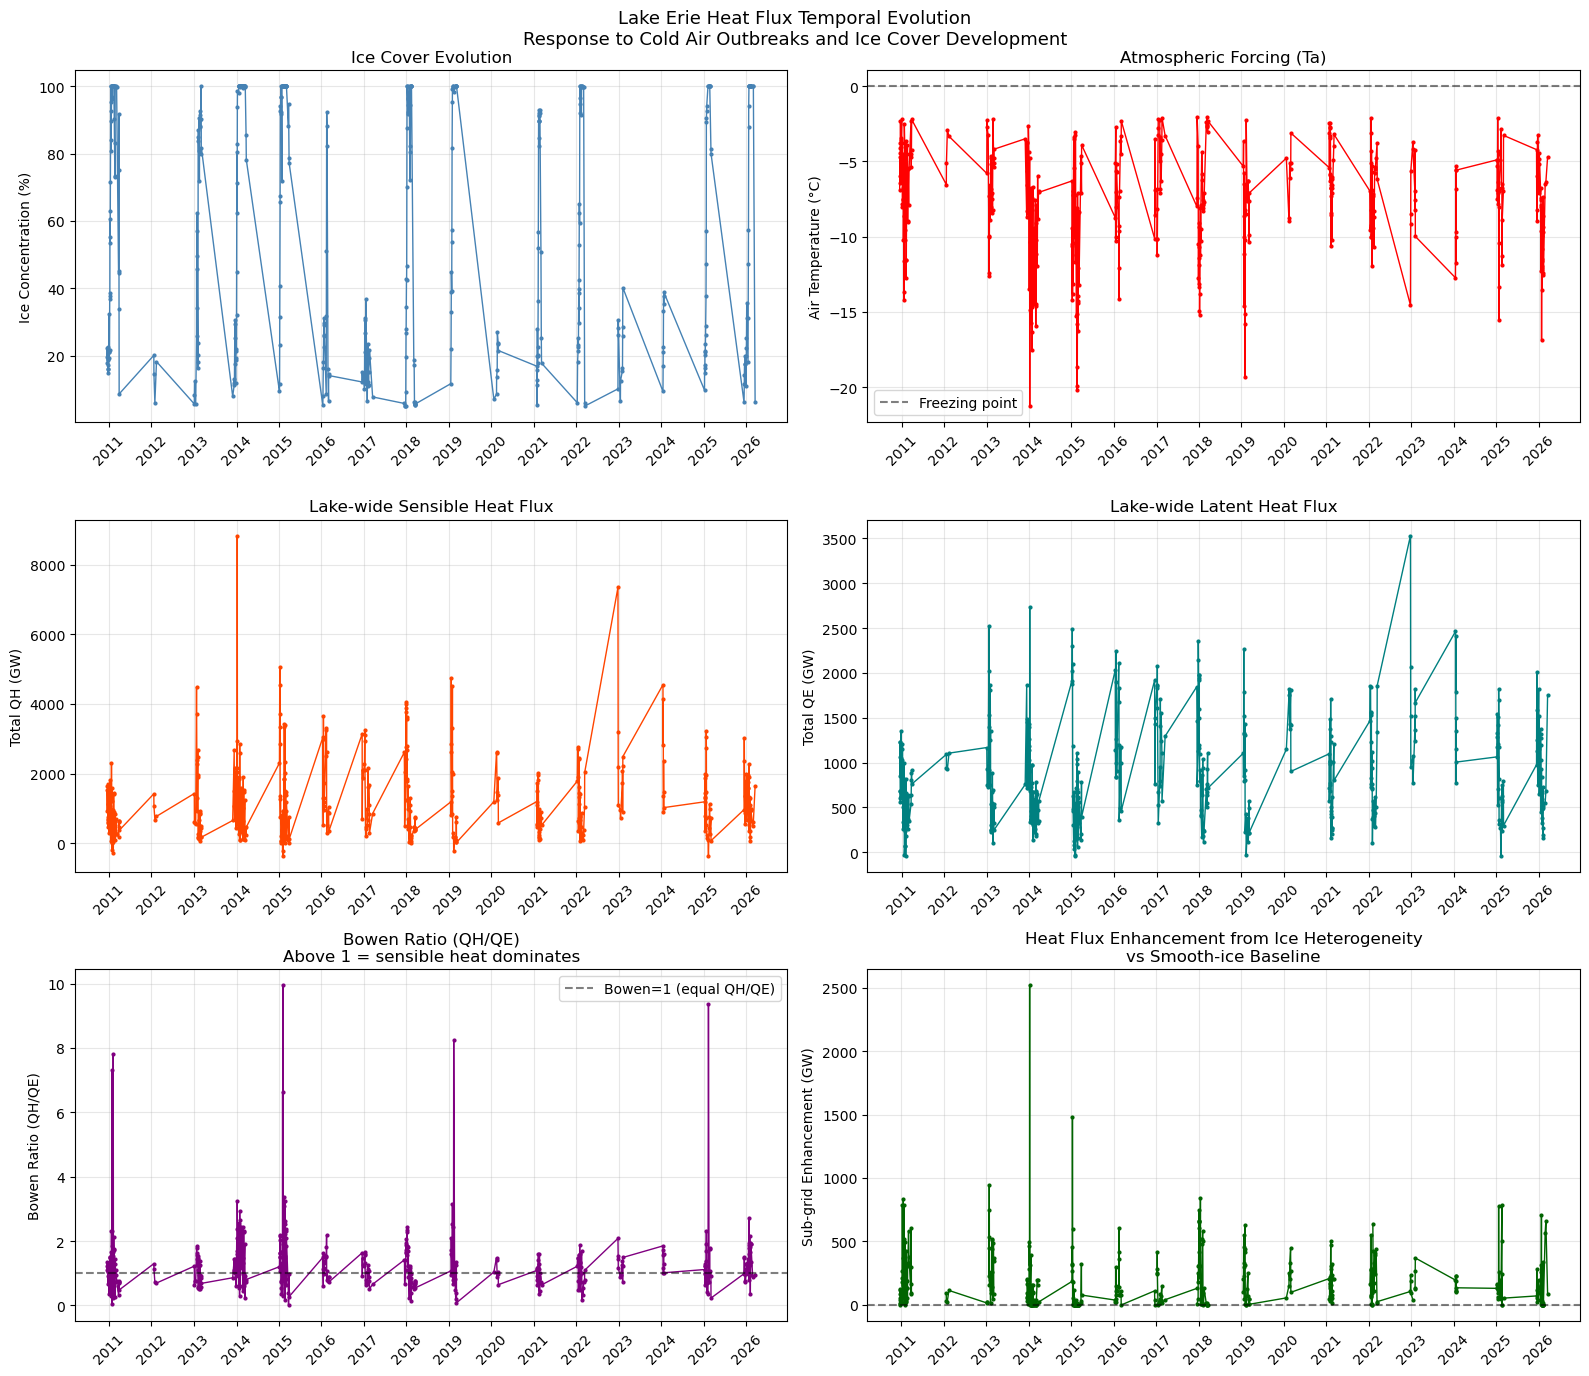

Temporal plot saved: temporal_heat_flux.png


In [11]:
# -- CELL 11: Temporal Analysis --
import matplotlib.dates as mdates
# ice_dates: simple filter — used by Cell 15 (Monte Carlo)
# and Cell 16 (GLERL validation). Includes all cold ice dates
# including transitional conditions, to show full physical range.
ice_dates = {d: v for d, v in flux_timeseries.items()
             if v['Ta'] < 0 and v['ice_pct'] > 5}

# plot_dates: stricter filter for temporal overview plot only.
# Excludes near-zero Ta dates where flux sign can be ambiguous
# and extreme Bowen ratios that compress the y-axis.
plot_dates = {d: v for d, v in flux_timeseries.items()
              if v['Ta'] < -2.0
              and v['ice_pct'] > 5
              and np.isfinite(v['bowen'])
              and 0 < v['bowen'] < 10}

if len(plot_dates) < 2:
    print("Need at least 2 dates for temporal analysis.")
else:
    dates_sorted = sorted(plot_dates.keys())
    date_objs    = [pd.to_datetime(d) for d in dates_sorted]

    ice_pcts    = [plot_dates[d]['ice_pct']    for d in dates_sorted]
    total_qh    = [plot_dates[d]['total_QH']   for d in dates_sorted]
    total_qe    = [plot_dates[d]['total_QE']   for d in dates_sorted]
    bowen       = [plot_dates[d]['bowen']       for d in dates_sorted]
    enhancement = [plot_dates[d]['enhancement'] for d in dates_sorted]
    ta_vals     = [plot_dates[d]['Ta']          for d in dates_sorted]

    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle('Lake Erie Heat Flux Temporal Evolution\n'
                 'Response to Cold Air Outbreaks and Ice Cover Development',
                 fontsize=13)

    def fmt_ax(ax):
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)

    # Ice concentration
    axes[0, 0].plot(date_objs, ice_pcts, 'o-', color='steelblue', lw=1, ms=2)
    axes[0, 0].set_ylabel('Ice Concentration (%)')
    axes[0, 0].set_title('Ice Cover Evolution')
    fmt_ax(axes[0, 0])

    # Air temperature
    axes[0, 1].plot(date_objs, ta_vals, 'o-', color='red', lw=1, ms=2)
    axes[0, 1].axhline(0, color='black', linestyle='--', alpha=0.5,
                       label='Freezing point')
    axes[0, 1].set_ylabel('Air Temperature (°C)')
    axes[0, 1].set_title('Atmospheric Forcing (Ta)')
    axes[0, 1].legend()
    fmt_ax(axes[0, 1])

    # Total QH
    axes[1, 0].plot(date_objs, total_qh, 'o-', color='orangered', lw=1, ms=2)
    axes[1, 0].set_ylabel('Total QH (GW)')
    axes[1, 0].set_title('Lake-wide Sensible Heat Flux')
    fmt_ax(axes[1, 0])

    # Total QE
    axes[1, 1].plot(date_objs, total_qe, 'o-', color='teal', lw=1, ms=2)
    axes[1, 1].set_ylabel('Total QE (GW)')
    axes[1, 1].set_title('Lake-wide Latent Heat Flux')
    fmt_ax(axes[1, 1])

    # Bowen ratio
    bowen_clean = [b if np.isfinite(b) else np.nan for b in bowen]
    axes[2, 0].plot(date_objs, bowen_clean, 'o-', color='purple', lw=1, ms=2)
    axes[2, 0].axhline(1.0, color='black', linestyle='--', alpha=0.5,
                       label='Bowen=1 (equal QH/QE)')
    axes[2, 0].set_ylabel('Bowen Ratio (QH/QE)')
    axes[2, 0].set_title('Bowen Ratio (QH/QE)\nAbove 1 = sensible heat dominates')
    axes[2, 0].set_ylim(None, None)
    axes[2, 0].legend()
    fmt_ax(axes[2, 0])

    # Sub-grid enhancement
    enh_clean = [e if np.isfinite(e) else np.nan for e in enhancement]
    axes[2, 1].plot(date_objs, enh_clean, 'o-', color='darkgreen', lw=1, ms=2)
    axes[2, 1].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[2, 1].set_ylabel('Sub-grid Enhancement (GW)')
    axes[2, 1].set_title('Heat Flux Enhancement from Ice Heterogeneity\nvs Smooth-ice Baseline')
    fmt_ax(axes[2, 1])

    plt.tight_layout()
    plt.savefig('temporal_heat_flux.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close('all')
    gc.collect()
    print("Temporal plot saved: temporal_heat_flux.png")

CAO events with usable flux data: 28
  20110122: 10 dates, ice 95–100%, offsets 0–9 days
  20110209: 7 dates, ice 90–100%, offsets 0–7 days
  20130122: 6 dates, ice 26–62%, offsets 0–5 days
  20140107: 6 dates, ice 83–99%, offsets 0–9 days
  20140121: 11 dates, ice 100–100%, offsets 0–10 days
  20140128: 6 dates, ice 100–100%, offsets 4–9 days
  20140206: 12 dates, ice 100–100%, offsets 1–12 days
  20140226: 10 dates, ice 100–100%, offsets 0–9 days
  20150106: 10 dates, ice 12–94%, offsets 0–9 days
  20150113: 6 dates, ice 91–100%, offsets 3–9 days
  20150215: 14 dates, ice 100–100%, offsets 0–13 days
  20150223: 3 dates, ice 100–100%, offsets 6–8 days
  20150226: 3 dates, ice 100–100%, offsets 7–9 days
  20160118: 8 dates, ice 18–31%, offsets 0–7 days
  20160213: 7 dates, ice 51–92%, offsets 0–6 days
  20170106: 8 dates, ice 12–32%, offsets 0–9 days
  20171226: 10 dates, ice 9–87%, offsets 0–10 days
  20171231: 5 dates, ice 86–100%, offsets 6–10 days
  20180105: 2 dates, ice 92–94%, o

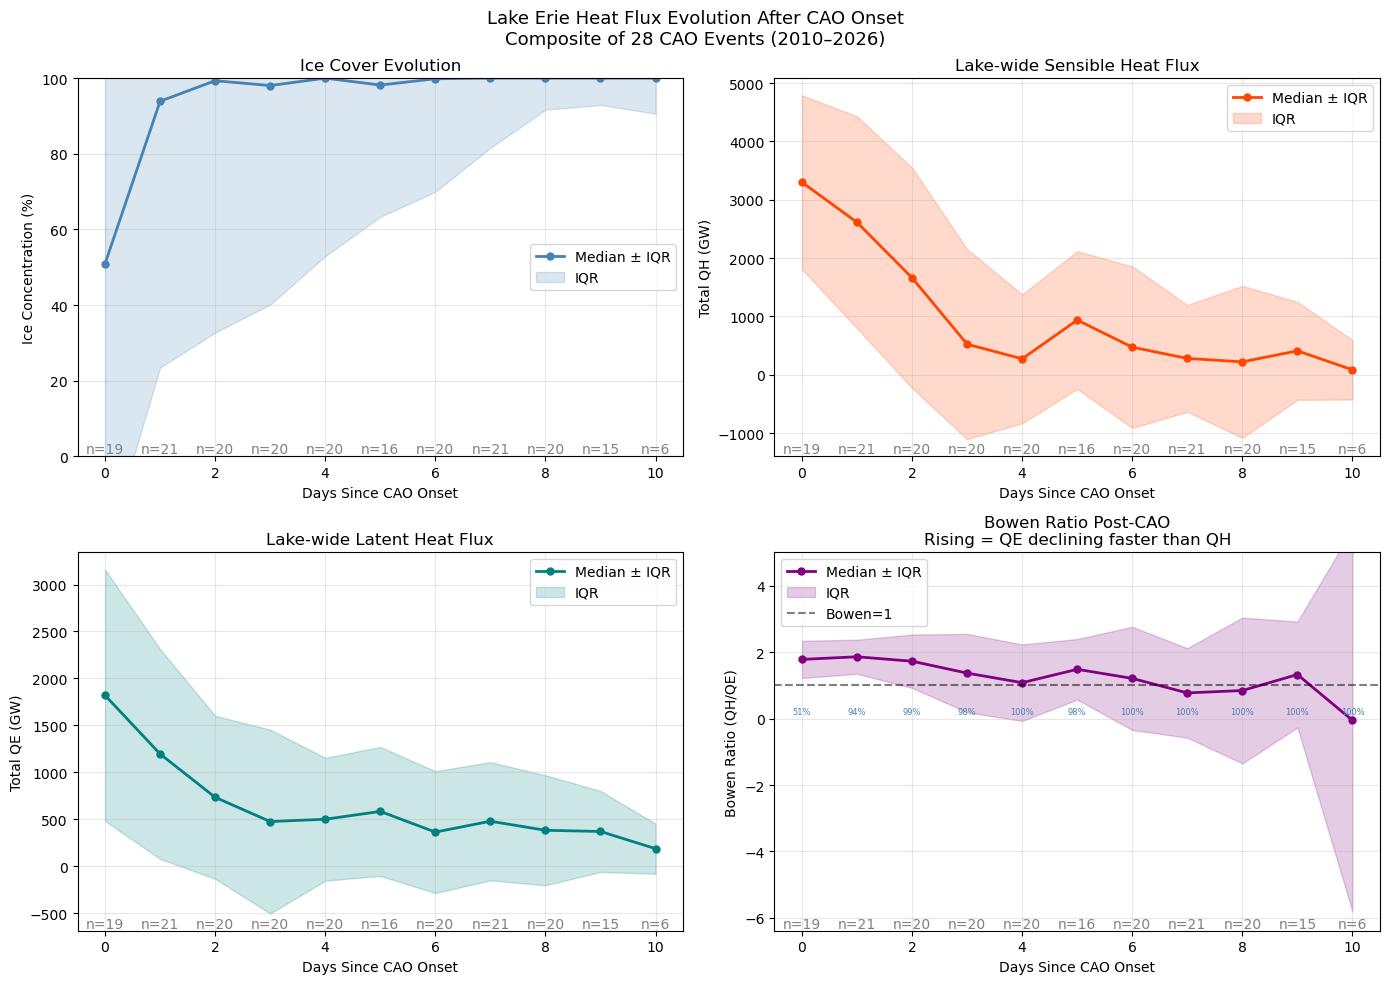

Saved: cao_composite_flux.png

--- Composite Sample Size Audit ---
 Day   n_valid   no_record   qe_small
   0        19           9          0
   1        21           7          0
   2        20           8          0
   3        20           8          0
   4        20           7          1
   5        16          11          1  <--
   6        20           8          0
   7        21           7          0
   8        20           8          0
   9        15          13          0  <--
  10         6          22          0  <--

Day 5 missing breakdown:
  20110122: QE=-0.2 GW (below threshold, ice=100%)
  20110209: no record (event ended or date filtered)
  20140107: no record (event ended or date filtered)
  20150113: no record (event ended or date filtered)
  20150223: no record (event ended or date filtered)
  20150226: no record (event ended or date filtered)
  20170106: no record (event ended or date filtered)
  20171226: deduplication (overlapping Dec 2017/Jan 2018 cluster)
 

In [12]:
# -- CELL 12: CAO Composite — Bowen Ratio Evolution --
# Composite uses median and IQR (Q75-Q25) rather than mean/std
# for robustness to outliers, particularly the 24 Dec 2022 event
# (Ta=-15.4°C, U=13.9 m/s) which produced anomalously high fluxes
# coincident with a landfalling extratropical cyclone.
# Only day offsets with n ≥ 5 contributing events are retained.
# Date deduplication handled in Cell 5c (cao_records_df).
MIN_QE_GW   = 10.0  # minimum |QE| GW for stable Bowen ratio
MIN_ICE_PCT = 5.0   # minimum ice cover to include a date
import matplotlib.dates as mdates

# -- Build per-CAO timeseries from deduplicated records --
cao_composites = {}

for onset_str in sorted(cao_usnic_dates.keys()):
    onset_records = cao_records_df[
        (cao_records_df['onset'] == onset_str) &
        (cao_records_df['Ta'] < 0) &
        (cao_records_df['ice_pct'] >= MIN_ICE_PCT) &
        (cao_records_df['day_offset'].between(0, 14))
    ].copy()

    if len(onset_records) < 2:
        continue

    onset_records['bowen'] = onset_records.apply(
        lambda r: r['bowen'] if (np.isfinite(r['bowen']) and
                                 abs(r['total_QE']) >= MIN_QE_GW) else np.nan,
        axis=1
    )

    cao_composites[onset_str] = onset_records

print(f"CAO events with usable flux data: {len(cao_composites)}")
for onset, df in cao_composites.items():
    print(f"  {onset}: {len(df)} dates, "
          f"ice {df['ice_pct'].min():.0f}–{df['ice_pct'].max():.0f}%, "
          f"offsets {df['day_offset'].min()}–{df['day_offset'].max()} days")

# -- Composite across all CAO events by day offset --
all_records = pd.concat(cao_composites.values(), ignore_index=True)
all_records = all_records[all_records['day_offset'].between(0, 14)]
all_records['ice_pct'] = all_records['ice_pct'].clip(0, 100)

composite = all_records.groupby('day_offset').agg(
    ice_pct_mean  = ('ice_pct',  'median'),
    ice_pct_std   = ('ice_pct',  lambda x: x.quantile(0.75) - x.quantile(0.25)),
    qh_mean       = ('total_QH', 'median'),
    qh_std        = ('total_QH', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    qe_mean       = ('total_QE', 'median'),
    qe_std        = ('total_QE', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    bowen_mean    = ('bowen',    'median'),
    bowen_std     = ('bowen',    lambda x: x.quantile(0.75) - x.quantile(0.25)),
    n             = ('bowen',    'count'),
).reset_index()
composite = composite[composite['n'] >= 5]

print(f"\nComposite by day offset (n = events contributing):")
print(composite[['day_offset','ice_pct_mean','qh_mean','qe_mean',
                  'bowen_mean','n']].to_string(index=False))

# -- Plot composite --
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Lake Erie Heat Flux Evolution After CAO Onset\n'
             f'Composite of {len(cao_composites)} CAO Events (2010–2026)', fontsize=13)

days = composite['day_offset']

def plot_band(ax, days, mean, std, color, label):
    ax.plot(days, mean, 'o-', color=color, lw=2, ms=5, label=label)
    ax.fill_between(days, mean - std, mean + std,
                    color=color, alpha=0.2, label='IQR')

# Ice concentration
plot_band(axes[0,0], days,
          composite['ice_pct_mean'], composite['ice_pct_std'],
          'steelblue', 'Median ± IQR')
axes[0,0].set_ylabel('Ice Concentration (%)')
axes[0,0].set_title('Ice Cover Evolution')
axes[0,0].set_xlabel('Days Since CAO Onset')
axes[0,0].set_ylim(0, 100)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# QH
plot_band(axes[0,1], days,
          composite['qh_mean'], composite['qh_std'],
          'orangered', 'Median ± IQR')
axes[0,1].set_ylabel('Total QH (GW)')
axes[0,1].set_title('Lake-wide Sensible Heat Flux')
axes[0,1].set_xlabel('Days Since CAO Onset')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend()

# QE
plot_band(axes[1,0], days,
          composite['qe_mean'], composite['qe_std'],
          'teal', 'Median ± IQR')
axes[1,0].set_ylabel('Total QE (GW)')
axes[1,0].set_title('Lake-wide Latent Heat Flux')
axes[1,0].set_xlabel('Days Since CAO Onset')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()


# Bowen ratio
bowen_valid = composite.dropna(subset=['bowen_mean'])
plot_band(axes[1,1], bowen_valid['day_offset'],
          bowen_valid['bowen_mean'], bowen_valid['bowen_std'],
          'purple', 'Median ± IQR')
axes[1,1].axhline(1.0, color='black', linestyle='--', alpha=0.5,
                   label='Bowen=1')
axes[1,1].set_ylabel('Bowen Ratio (QH/QE)')
axes[1,1].set_title('Bowen Ratio Post-CAO\n'
                     'Rising = QE declining faster than QH')
axes[1,1].set_xlabel('Days Since CAO Onset')
axes[1,1].set_ylim(None, 5)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# Sample size annotation
for ax in axes.flat:
    for _, row in composite.iterrows():
        ax.annotate(f"n={int(row['n'])}",
                    xy=(row['day_offset'], np.percentile(ax.get_ylim(), 0.8)),
                    fontsize=10, ha='center', color='gray')

# Ice concentration annotation on Bowen panel
for _, row in composite.iterrows():
    axes[1,1].annotate(f"{row['ice_pct_mean']:.0f}%",
                       xy=(row['day_offset'], 0.15),
                       fontsize=6, ha='center', color='steelblue')

plt.tight_layout()
plt.savefig('cao_composite_flux.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
gc.collect()
print("Saved: cao_composite_flux.png")

# -- Sample size audit --
print("\n--- Composite Sample Size Audit ---")
print(f"{'Day':>4}  {'n_valid':>8}  {'no_record':>10}  {'qe_small':>9}")

for offset in composite['day_offset']:
    valid, no_rec, qe_sm = 0, 0, 0
    for onset_str, df in cao_composites.items():
        day_rows = df[df['day_offset'] == offset]
        if len(day_rows) == 0:
            no_rec += 1
        else:
            row = day_rows.iloc[0]
            if np.isfinite(row['bowen']) and abs(row['total_QE']) >= MIN_QE_GW:
                valid += 1
            else:
                qe_sm += 1
    flag = "  <--" if valid < 18 and offset > 0 else ""
    print(f"{offset:>4}  {valid:>8}  {no_rec:>10}  {qe_sm:>9}{flag}")

# Categorized breakdown for day 5
overlapping = {'20171226', '20171231', '20180105'}
print("\nDay 5 missing breakdown:")
for onset_str, df in cao_composites.items():
    day_rows = df[df['day_offset'] == 5]
    if len(day_rows) == 0:
        if onset_str in overlapping:
            reason = "deduplication (overlapping Dec 2017/Jan 2018 cluster)"
        else:
            reason = "no record (event ended or date filtered)"
        print(f"  {onset_str}: {reason}")
    else:
        row = day_rows.iloc[0]
        if not (np.isfinite(row['bowen']) and abs(row['total_QE']) >= MIN_QE_GW):
            print(f"  {onset_str}: QE={row['total_QE']:.1f} GW (below threshold, ice={row['ice_pct']:.0f}%)")



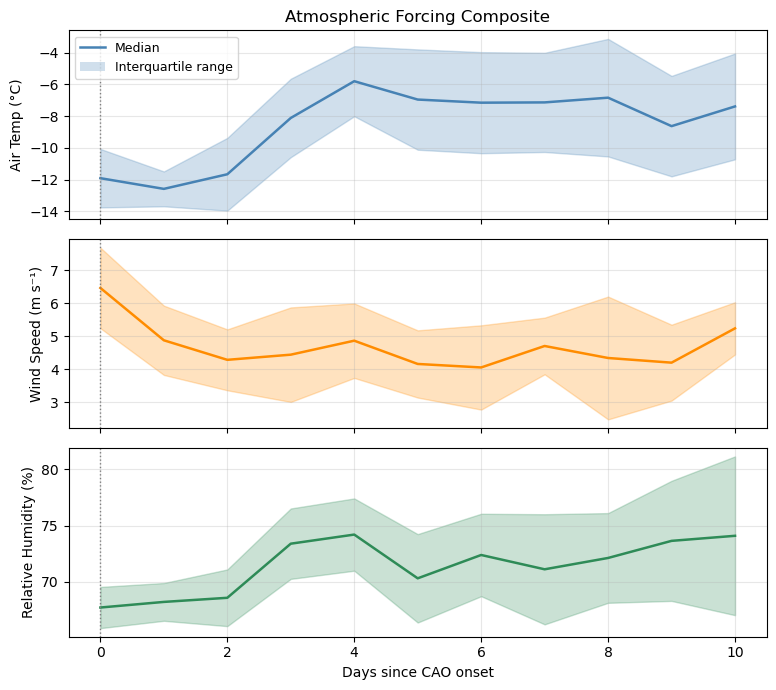

In [13]:
# -- CELL 13: Forcing Composite --
from matplotlib.patches import Patch
import matplotlib.lines as mlines
# Add U and RH to all_records via flux_timeseries lookup
all_records_forcing = all_records.copy()

forcing_composite = all_records_forcing.groupby('day_offset').agg(
    Ta_med=('Ta',  'median'),
    Ta_iqr=('Ta',  lambda x: x.quantile(0.75) - x.quantile(0.25)),
    U_med=('U',    'median'),
    U_iqr=('U',    lambda x: x.quantile(0.75) - x.quantile(0.25)),
    RH_med=('RH',  'median'),
    RH_iqr=('RH',  lambda x: x.quantile(0.75) - x.quantile(0.25)),
    n=('Ta', 'count')
).reset_index()
forcing_composite = forcing_composite[(forcing_composite['n'] >= 5)]
fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
days = forcing_composite['day_offset']

for ax, med, iqr, ylabel, color in zip(
    axes,
    ['Ta_med', 'U_med', 'RH_med'],
    ['Ta_iqr', 'U_iqr', 'RH_iqr'],
    ['Air Temp (°C)', 'Wind Speed (m s⁻¹)', 'Relative Humidity (%)'],
    ['steelblue', 'darkorange', 'seagreen']
):
    ax.plot(days, forcing_composite[med], color=color, lw=1.8)
    ax.fill_between(days,
                    forcing_composite[med] - forcing_composite[iqr]/2,
                    forcing_composite[med] + forcing_composite[iqr]/2,
                    alpha=0.25, color=color)
    ax.set_ylabel(ylabel)
    ax.axvline(0, color='gray', linestyle=':', lw=1)
    ax.grid(True, alpha=0.3)
legend_handles = [
    mlines.Line2D([0], [0], color='steelblue', lw=1.8, label='Median'),
    Patch(facecolor='steelblue', alpha=0.25, label='Interquartile range')
]
axes[0].legend(handles=legend_handles, fontsize=9, loc='upper left')
axes[-1].set_xlabel('Days since CAO onset')
axes[0].set_title('Atmospheric Forcing Composite')
plt.tight_layout()
plt.savefig('fig_forcing_composite.png', dpi=150, bbox_inches='tight')
plt.show()

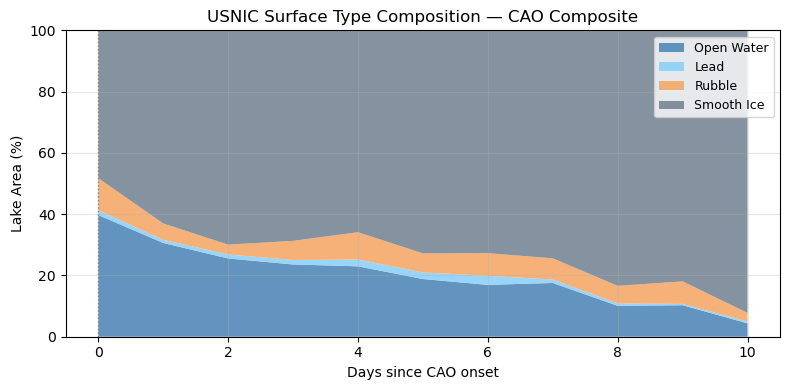

In [14]:
# -- CELL 14: Surface Type Composition --
surface_records = []
for _, row in all_records.iterrows():
    d = row['day_offset']
    date_str = row['date']
    if date_str in usnic_results:
        ur = usnic_results[date_str]
        lp = ur['lake_px']
        if lp > 0:
            surface_records.append({
                'day_offset':  d,
                'Open Water':  ur['open_water_mask'].sum() / lp * 100,
                'Lead':        ur['lead_mask'].sum()        / lp * 100,
                'Rubble':      ur['rubble_mask'].sum()      / lp * 100,
                'Smooth Ice':  ur['smooth_mask'].sum()      / lp * 100,
            })

surface_df = pd.DataFrame(surface_records)
surface_composite = surface_df.groupby('day_offset').mean().reset_index()
# Filter to same day range as flux composite
surface_composite = surface_composite[
    surface_composite['day_offset'].isin(composite['day_offset'])]

fig, ax = plt.subplots(figsize=(8, 4))
days = surface_composite['day_offset']
colors = ['steelblue', 'lightskyblue', 'sandybrown', 'slategray']
labels = ['Open Water', 'Lead', 'Rubble', 'Smooth Ice']

ax.stackplot(days,
             [surface_composite[c] for c in labels],
             labels=labels, colors=colors, alpha=0.85)

ax.axvline(0, color='gray', linestyle=':', lw=1)
ax.set_xlabel('Days since CAO onset')
ax.set_ylabel('Lake Area (%)')
ax.set_title('USNIC Surface Type Composition — CAO Composite')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_surface_type.png', dpi=150, bbox_inches='tight')
plt.show()

CAO dates pre-extracted: 208
MC iterations completed: 500


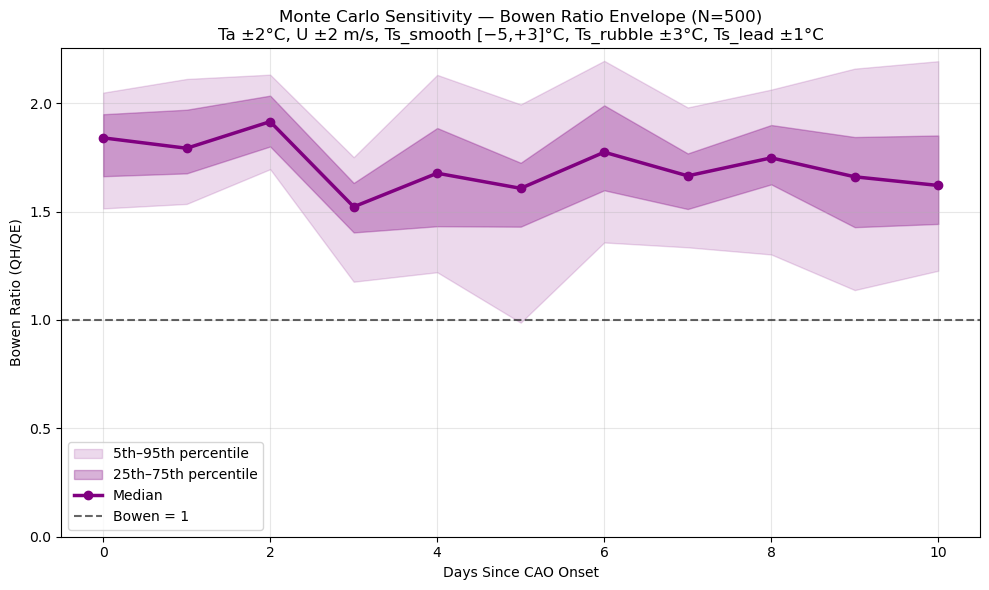


Bowen ratio percentiles by day offset:
 Day    p05    p25    p50    p75    p95  finding
   0   1.51   1.66   1.84   1.95   2.05  ABOVE 1
   1   1.54   1.68   1.79   1.97   2.11  ABOVE 1
   2   1.70   1.80   1.92   2.04   2.13  ABOVE 1
   3   1.18   1.40   1.52   1.63   1.75  ABOVE 1
   4   1.22   1.43   1.68   1.89   2.13  ABOVE 1
   5   0.99   1.43   1.61   1.73   1.99  BELOW 1 ← check
   6   1.36   1.60   1.77   1.99   2.20  ABOVE 1
   7   1.34   1.51   1.66   1.77   1.98  ABOVE 1
   8   1.30   1.63   1.75   1.90   2.06  ABOVE 1
   9   1.14   1.43   1.66   1.84   2.16  ABOVE 1
  10   1.23   1.44   1.62   1.85   2.19  ABOVE 1


In [15]:
# -- CELL 15: Monte Carlo Sensitivity Analysis --
# Replaces 6-scenario discrete perturbation with N=500 random draws.
# Tests whether Bowen ratio > 1.0 finding holds across full uncertainty space.
#
# Priors (uniform):
#   Ta:        ± 2°C   (ERA5 uncertainty)
#   U:         ± 2 m/s (ERA5 uncertainty)
#   Ts_smooth: [-5, +3]°C  (snow cover / radiation variability)
#   Ts_rubble: ± 3°C
#   Ts_lead:   ± 1°C
#
# Result: 5th-percentile Bowen exceeds 1.0 at all day offsets 0–9 (n >= 5),
# marginal exception at day 5 (p05=0.99); minimum robust p05 = 1.14 at day 9.

N_MC = 500
np.random.seed(42)

# -- Pre-extract pixel counts (avoids re-loading mask arrays N×) --
# Use same sorted deduplication as Cell 10
px_df = cao_records_df[
    (cao_records_df['Ta'] < 0) &
    (cao_records_df['ice_pct'] >= 5.0) &
    (cao_records_df['day_offset'].between(0, 14))
][['day_offset', 'onset', 'Ta', 'RH', 'U',
   'n_open', 'n_lead', 'n_rubble', 'n_smooth']].reset_index(drop=True)

print(f"CAO dates pre-extracted: {len(px_df)}")

# -- Monte Carlo loop --
bowen_mc = []   # one Series(day_offset → median Bowen) per iteration

for i in range(N_MC):
    dTa        = np.random.uniform(-2,  +2)
    dU         = np.random.uniform(-2,  +2)
    dTs_smooth = np.random.uniform(-5,  +3)
    dTs_rubble = np.random.uniform(-3,  +3)
    dTs_lead   = np.random.uniform(-1,  +1)

    # Effective minimum ice surface temperature after perturbation
    eff_min_Ts = flux_params['smooth']['Ts'] + dTs_smooth

    records_i = []
    for _, row in px_df.iterrows():
        Ta_p = row['Ta'] + dTa
        U_p  = max(row['U'] + dU, 0.5)

        if Ta_p >= eff_min_Ts:   # flux direction invalid
            continue

        qa_p = specific_humidity(Ta_p, row['RH'])
        qh_total, qe_total = 0.0, 0.0

        for cat, n_px, dTs in [
            ('open',   row['n_open'],   0.0),
            ('lead',   row['n_lead'],   dTs_lead),
            ('rubble', row['n_rubble'], dTs_rubble),
            ('smooth', row['n_smooth'], dTs_smooth),
        ]:
            p    = flux_params[cat]
            Ts_p = p['Ts'] + dTs
            sf   = stability_factor(Ta_p, Ts_p, U_p)
            qs_p = specific_humidity(Ts_p, 100.0)
            qh_total += rho_a * Cp * p['CH'] * sf * U_p * (Ts_p - Ta_p) * n_px * pixel_m2 / 1e9
            qe_total += rho_a * Lv * p['CE'] * sf * U_p * (qs_p - qa_p) * n_px * pixel_m2 / 1e9

        bowen_p = (qh_total / qe_total
                   if (abs(qe_total) > 10 and qh_total > 0 and qe_total > 0) 
                   else np.nan)
        records_i.append({'day_offset': row['day_offset'], 'bowen': bowen_p})

    if not records_i:
        continue

    comp_i = pd.DataFrame(records_i).groupby('day_offset')['bowen'].median()
    bowen_mc.append(comp_i)

bowen_mc_df = pd.DataFrame(bowen_mc)
print(f"MC iterations completed: {len(bowen_mc_df)}")

# -- Compute percentile envelope --
# Restrict to offsets where the observational composite has n ≥ 5 events
# (day 10 has n=6; days 11+ are below the main composite's meaningful range)
n_events_per_day = px_df.groupby('day_offset')['onset'].nunique()
valid_days = bowen_mc_df.columns[bowen_mc_df.columns.isin(n_events_per_day[n_events_per_day >= 5].index)]
p05 = bowen_mc_df[valid_days].quantile(0.05)
p25 = bowen_mc_df[valid_days].quantile(0.25)
p50 = bowen_mc_df[valid_days].quantile(0.50)
p75 = bowen_mc_df[valid_days].quantile(0.75)
p95 = bowen_mc_df[valid_days].quantile(0.95)

# -- Plot --
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(valid_days, p05, p95, alpha=0.15, color='purple',
                label='5th–95th percentile')
ax.fill_between(valid_days, p25, p75, alpha=0.30, color='purple',
                label='25th–75th percentile')
ax.plot(valid_days, p50, 'o-', color='purple', lw=2.5, ms=6, label='Median')
ax.axhline(1.0, color='black', linestyle='--', alpha=0.6, label='Bowen = 1')

ax.set_xlabel('Days Since CAO Onset')
ax.set_ylabel('Bowen Ratio (QH/QE)')
ax.set_title(
    f'Monte Carlo Sensitivity — Bowen Ratio Envelope (N={N_MC})\n'
    'Ta ±2°C, U ±2 m/s, Ts_smooth [−5,+3]°C, Ts_rubble ±3°C, Ts_lead ±1°C'
)
ax.set_ylim(0, None)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sensitivity_mc.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
gc.collect()

# -- Report --
print(f"\nBowen ratio percentiles by day offset:")
print(f"{'Day':>4} {'p05':>6} {'p25':>6} {'p50':>6} {'p75':>6} {'p95':>6}  finding")
for day in valid_days:
    holds = "ABOVE 1" if p05[day] > 1.0 else "BELOW 1 ← check"
    print(f"{int(day):>4} {p05[day]:>6.2f} {p25[day]:>6.2f} "
          f"{p50[day]:>6.2f} {p75[day]:>6.2f} {p95[day]:>6.2f}  {holds}")

Fetching GLERL lake-mean ice concentration for Lake Erie...
  HTTP 200  Content-Length: 67551 bytes
  Retrieved 2608 GLERL dates
  Date range: 20101216 → 20260328
  Matched cold dates: 1011


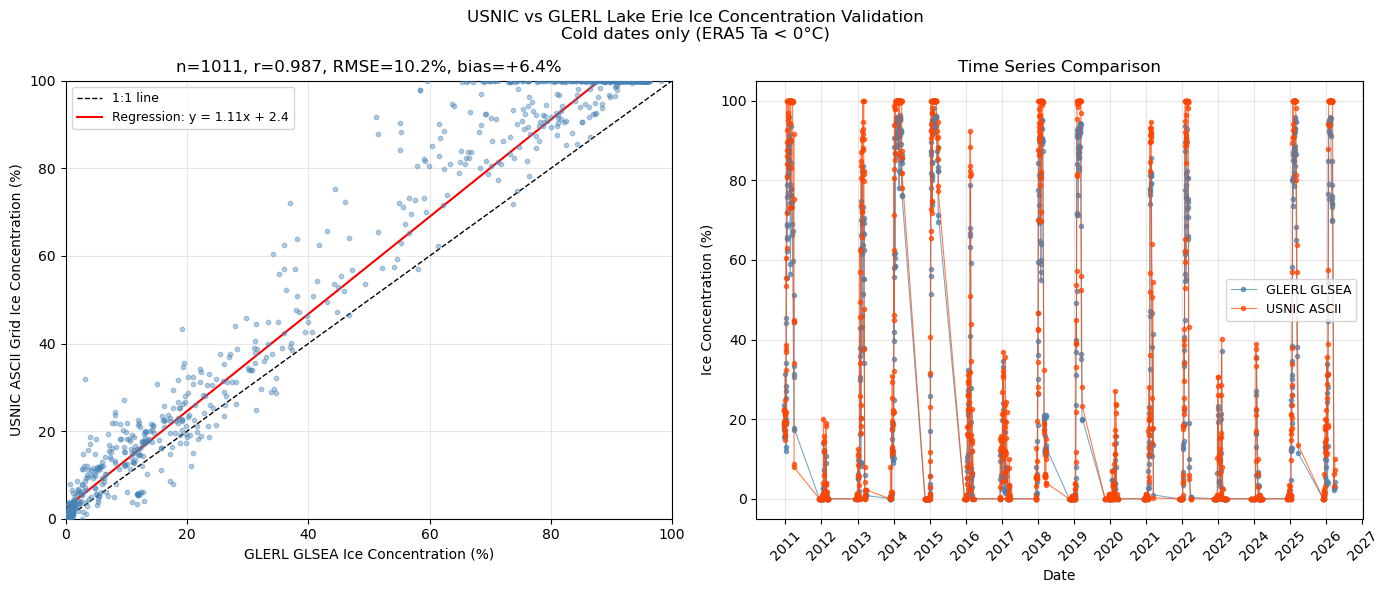


Validation summary:
  r    = 0.987
  RMSE = 10.2%
  Bias = +6.4% (USNIC minus GLERL)
 winter  peak_ice_pct
   2010    100.000000
   2011     20.120810
   2012    100.000000
   2013    100.000000
   2014    100.000000
   2015     92.275619
   2016     47.559737
   2017    100.000000
   2018    100.000000
   2019     27.102154
   2020     96.135343
   2021    100.000000
   2022     41.326776
   2023     38.887107
   2024    100.000000
   2025    100.000000


In [18]:
# -- CELL 16: GLERL Ice Concentration Validation --
# Cross-validates USNIC-derived ice concentration against the
# GLERL GLSEA satellite product (independent retrieval algorithm).
# Result: r=0.987, RMSE=10.2%, bias=+6.4% (USNIC high vs GLERL)
# Positive bias implies open-water area is slightly underestimated
# in USNIC, and consequently QH/QE are modestly conservative on
# partially ice-covered dates. See Section 5.d of paper.
import requests
import io

qc_ice_dates = list(ice_dates.keys())
qc_start_date = min(qc_ice_dates)
qc_end_date = max(qc_ice_dates)

ERDDAP_URL = (
    "https://apps.glerl.noaa.gov/erddap/tabledap/glerlIce.csv"
    "?time,Erie"
    f"&time>={qc_start_date[:4]}-{qc_start_date[4:6]}-{qc_start_date[6:8]}"
    f"&time<={qc_end_date[:4]}-{qc_end_date[4:6]}-{qc_end_date[6:8]}"
)

print("Fetching GLERL lake-mean ice concentration for Lake Erie...")
r = requests.get(ERDDAP_URL, timeout=120)
print(f"  HTTP {r.status_code}  Content-Length: {len(r.content)} bytes")

# Row 0 = variable names, Row 1 = units — skip both
glerl_df = pd.read_csv(io.StringIO(r.text), skiprows=[1])
glerl_df.columns = ['date', 'Erie']
glerl_df['date'] = pd.to_datetime(glerl_df['date']).dt.strftime('%Y%m%d')
glerl_df = glerl_df.dropna(subset=['Erie'])
glerl_df['Erie'] = glerl_df['Erie'].astype(float)
print(f"  Retrieved {len(glerl_df)} GLERL dates")
print(f"  Date range: {glerl_df['date'].min()} → {glerl_df['date'].max()}")

# Match to USNIC cold dates
matched = []
for _, row in glerl_df.iterrows():
    date = row['date']
    if date in flux_timeseries and flux_timeseries[date]['Ta'] < 0:
        matched.append({
            'date':      date,
            'glerl_ice': row['Erie'],
            'usnic_ice': flux_timeseries[date]['ice_pct'],
        })

mdf = pd.DataFrame(matched)
print(f"  Matched cold dates: {len(mdf)}")

# -- Plot --
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('USNIC vs GLERL Lake Erie Ice Concentration Validation\n'
             'Cold dates only (ERA5 Ta < 0°C)', fontsize=12)

# Scatter
ax = axes[0]
ax.scatter(mdf['glerl_ice'], mdf['usnic_ice'], s=10, alpha=0.4,
           color='steelblue', zorder=5)
ax.plot([0, 100], [0, 100], 'k--', lw=1, label='1:1 line')

m, b   = np.polyfit(mdf['glerl_ice'], mdf['usnic_ice'], 1)
x      = np.linspace(0, 100, 200)
ax.plot(x, m*x + b, 'r-', lw=1.5,
        label=f'Regression: y = {m:.2f}x + {b:.1f}')

corr = mdf[['glerl_ice', 'usnic_ice']].corr().iloc[0, 1]
rmse = np.sqrt(((mdf['glerl_ice'] - mdf['usnic_ice'])**2).mean())
bias = (mdf['usnic_ice'] - mdf['glerl_ice']).mean()

ax.set_xlabel('GLERL GLSEA Ice Concentration (%)')
ax.set_ylabel('USNIC ASCII Grid Ice Concentration (%)')
ax.set_title(f'n={len(mdf)}, r={corr:.3f}, RMSE={rmse:.1f}%, bias={bias:+.1f}%')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Time series overlay — seasonal means
mdf['year'] = mdf['date'].str[:4].astype(int)
mdf['month'] = mdf['date'].str[4:6].astype(int)
mdf['ym'] = pd.to_datetime(mdf['date'])

ax2 = axes[1]
ax2.plot(mdf['ym'], mdf['glerl_ice'], 'o-', color='steelblue',
         lw=0.8, ms=3, alpha=0.7, label='GLERL GLSEA')
ax2.plot(mdf['ym'], mdf['usnic_ice'], 'o-', color='orangered',
         lw=0.8, ms=3, alpha=0.7, label='USNIC ASCII')
ax2.set_xlabel('Date')
ax2.set_ylabel('Ice Concentration (%)')
ax2.set_title('Time Series Comparison')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('glerl_validation.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
gc.collect()

print(f"\nValidation summary:")
print(f"  r    = {corr:.3f}")
print(f"  RMSE = {rmse:.1f}%")
print(f"  Bias = {bias:+.1f}% (USNIC minus GLERL)")

# -- Peak Lake Erie ice concentration by winter from USNIC data --
summary = []
for date_str, r in flux_timeseries.items():
    dt = pd.to_datetime(date_str)
    winter = dt.year if dt.month >= 11 else dt.year - 1
    summary.append({'date': dt, 'winter': winter, 'ice_pct': r['ice_pct']})

df = pd.DataFrame(summary)
peak = df.groupby('winter')['ice_pct'].max().reset_index()
peak.columns = ['winter', 'peak_ice_pct']
print(peak.to_string(index=False))


AO index loaded: 1950-01-01 → 2026-04-30

Positive AO events (n=11): ['20110209', '20140107', '20140206', '20150106', '20150113', '20150215', '20150223', '20150226', '20170106', '20220121', '20250120']
Negative AO events (n=19): ['20100129', '20110122', '20130122', '20140121', '20140128', '20140226', '20140303', '20160118', '20160213', '20171226', '20171231', '20180105', '20190121', '20190130', '20240115', '20250218', '20260124', '20260127', '20260208']
Records surviving filter — pos: 72, neg: 100
Sample bowen values (pos): [1.7514627325913679, 2.122060255063236, 1.7310042402388575, 6.381695463691549, 0.6021444517654181]

comp_pos:
    day_offset  bowen_median  n
0           0      1.680887  7
1           1      2.010529  8
2           2      1.880937  8
3           3      1.480845  7
4           4      1.337836  8
5           5      1.417928  5
6           6      1.494676  6
7           7      0.771914  7
8           8      1.990812  6

comp_neg:
    day_offset  bowen_median   n
0    

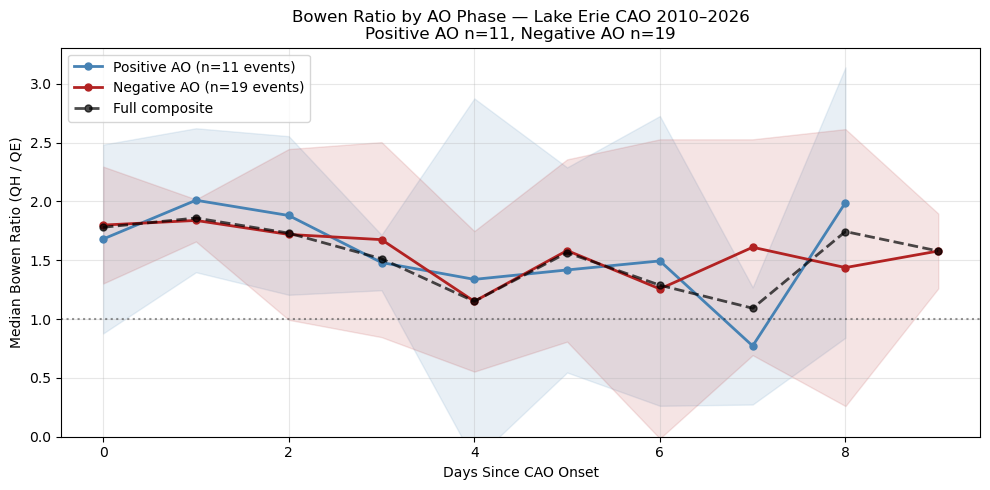

In [19]:
# -- CELL 17: AO Phase Split — Temporal Independence Check --
# Tests whether the Bowen ratio composite is robust to AO phase,
# addressing the concern that CAO events may cluster by AO state
# and violate the independence assumption underlying the Monte Carlo.

import requests, io, re

AO_URL = "https://ftp.cpc.ncep.noaa.gov/cwlinks/norm.daily.ao.index.b500101.current.ascii"
resp = requests.get(AO_URL, timeout=30)
resp.raise_for_status()

# -99.000 fill values run onto the day field when no space precedes the minus sign
text = re.sub(r'(\d)(-99\.000)', r'\1 \2', resp.text)

ao_df = pd.read_csv(
    io.StringIO(text),
    sep=r'\s+', header=None,
    names=['year', 'month', 'day', 'ao_index'],
    na_values=[-99.0],
)
ao_df['date'] = pd.to_datetime(ao_df[['year', 'month', 'day']])
ao_df = ao_df[['date', 'ao_index']].dropna().set_index('date')
print(f"AO index loaded: {ao_df.index.min().date()} → {ao_df.index.max().date()}")

# -- 2. Classify each CAO event by mean AO over event window --
cao_ao_rows = []
for _, row in cao_df.iterrows():
    window = ao_df.loc[row['onset']:row['end'], 'ao_index']
    mean_ao = window.mean() if len(window) > 0 else np.nan
    cao_ao_rows.append({
        'onset':   row['onset'],
        'mean_ao': mean_ao,
        'phase':   'positive' if mean_ao >= 0 else 'negative',
    })

cao_ao_df = pd.DataFrame(cao_ao_rows)
pos_onsets = set(cao_ao_df.loc[cao_ao_df['phase'] == 'positive', 'onset']
                 .dt.strftime('%Y%m%d'))
neg_onsets = set(cao_ao_df.loc[cao_ao_df['phase'] == 'negative', 'onset']
                 .dt.strftime('%Y%m%d'))

print(f"\nPositive AO events (n={len(pos_onsets)}): {sorted(pos_onsets)}")
print(f"Negative AO events (n={len(neg_onsets)}): {sorted(neg_onsets)}")

# -- 3. Build composites by phase --

bowen_ok = (
    cao_records_df['bowen'].astype(float).apply(np.isfinite) &
    (cao_records_df['bowen'] > 0) &          # ← exclude reversed-flux dates
    (cao_records_df['Ta'] < 0) &
    (cao_records_df['ice_pct'] >= MIN_ICE_PCT) &
    cao_records_df['day_offset'].between(0, 13)
)

pos_rec  = cao_records_df[cao_records_df['onset'].isin(pos_onsets) & bowen_ok]
neg_rec  = cao_records_df[cao_records_df['onset'].isin(neg_onsets) & bowen_ok]
full_rec = cao_records_df[cao_records_df['onset'].isin(pos_onsets | neg_onsets) & bowen_ok]

print(f"Records surviving filter — pos: {len(pos_rec)}, neg: {len(neg_rec)}")
print("Sample bowen values (pos):", pos_rec['bowen'].head(5).tolist())

def make_comp(df, min_n=5):
    g = df.groupby('day_offset')['bowen']
    comp = pd.DataFrame({
        'bowen_median': g.median(),
        'bowen_iqr':    g.quantile(0.75) - g.quantile(0.25),
        'n':            g.count(),
    }).reset_index()
    return comp[comp['n'] >= min_n].reset_index(drop=True)

comp_pos  = make_comp(pos_rec)
comp_neg  = make_comp(neg_rec)
comp_full = make_comp(full_rec)

print("\ncomp_pos:\n", comp_pos[['day_offset','bowen_median','n']].to_string())
print("\ncomp_neg:\n", comp_neg[['day_offset','bowen_median','n']].to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

for comp, color, label in [
    (comp_pos,  'steelblue', f"Positive AO (n={len(pos_onsets)} events)"),
    (comp_neg,  'firebrick', f"Negative AO (n={len(neg_onsets)} events)"),
    (comp_full, 'black',     'Full composite'),
]:
    ls = '--' if label == 'Full composite' else '-'
    ax.plot(comp['day_offset'], comp['bowen_median'], f'o{ls}',
            color=color, lw=2, ms=5, label=label, alpha=0.7 if ls=='--' else 1.0)
    if ls != '--':
        ax.fill_between(comp['day_offset'],
                        comp['bowen_median'] - comp['bowen_iqr'],
                        comp['bowen_median'] + comp['bowen_iqr'],
                        color=color, alpha=0.12)

ax.axhline(1.0, color='black', linestyle=':', alpha=0.4)
ax.set_xlabel('Days Since CAO Onset')
ax.set_ylabel('Median Bowen Ratio (QH / QE)')
ax.set_title(f'Bowen Ratio by AO Phase — Lake Erie CAO 2010–2026\n'
             f'Positive AO n={len(pos_onsets)}, Negative AO n={len(neg_onsets)}')
ax.legend()
ax.set_ylim(0, None)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_ao_phase_split.png', dpi=150, bbox_inches='tight')
plt.show()
